# 04. 수익 구조 분해 — Net Lift vs Cannibalization

**분석 목적:** 리워드 지출이 실제 추가 매출을 만드는가, 아니면 오퍼 없이 구매할 고객에게 비용이 추가되는 구조인가?  
**데이터:** `starbucks_EDA_data.csv`  

**수익 구조 분해:**

```
전체 리워드 지출
    ├── 기여 매출 (Net Lift > 0)   → 오퍼가 구매를 유도
    └── 잠식 매출 (Cannibalization) → 오퍼 없이도 구매했을 고객에게 리워드가 지급되는 잠식 구조
```

**핵심 발견:**

| 지표 | 수치 | 의미 |
|------|------|------|
| 우연완료 비중 | **16.5%** | 오퍼를 확인하지 않았음에도 구매가 발생 — 마케팅 기여 없이 리워드 지급 |
| 마케팅 효율 (Net Lift 기준) | **0.34** | $1 투자 시 $0.34 순 증대 매출 발생 |
| 잠식 매출 | 순 증대 매출의 **3배** | 오퍼로 번 돈보다 잠식이 더 많음 |

---

## 0. 환경 설정

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import warnings
warnings.filterwarnings("ignore")

plt.rc("font", family="sans-serif")  # Windows: Malgun Gothic
plt.rcParams["axes.unicode_minus"] = False

In [2]:
# starbucks_EDA_data.csv:  분석용 데이터셋
# 우연완료 식별, 오퍼 영향 판정, 세그먼트 컬럼이 포함된 통합 데이터
df = pd.read_csv("../data/processed/starbucks_EDA_data.csv")

## 1. 데이터 컬럼 구조

| 컬럼 그룹 | 컬럼 | 설명 |
|-----------|------|------|
| 행동 로그 | event, time, offer_id_unified | 수신/조회/완료 이벤트 |
| 오퍼 추적 | offer_id_view, offer_id_comp | 확인·완료된 오퍼 ID |
| 경제 지표 | amount, reward | 결제액 · 지급 리워드 |
| 세그먼트 | user_type, income_group, age_group | 고객 분류 |

---

In [3]:
# 오퍼별 수령, 조회, 완료횟수 집계
offer_stats = df.groupby(['offer_id_unified', 'offer_type'])['event'].agg([
    ('received', lambda x: (x == 'offer received').sum()),
    ('viewed', lambda x: (x == 'offer viewed').sum()),
    ('completed', lambda x: (x == 'offer completed').sum())
]).reset_index()

# 전환율 계산
offer_stats['view_rate'] = (offer_stats['viewed'] / offer_stats['received']) * 100
offer_stats['comp_rate'] = (offer_stats['completed'] / offer_stats['received']) * 100

display(offer_stats.sort_values('comp_rate', ascending=False))

,offer_id_unified,offer_type,received,viewed,completed,view_rate,comp_rate
9,fafdcd668e3743c1bb461111dcafc2a4,discount,6652,6407,5003,96.316897,75.210463
1,2298d6c36e964ae4a3e7e9706d1fb8c2,discount,6655,6379,4886,95.852742,73.418482
6,9b98b8c7a33c4b65b9aebfe6a799e6d9,bogo,6685,3499,4188,52.341062,62.647719
8,f19421c1d4aa40978ebb69ca19b0e20d,bogo,6576,6310,4103,95.954988,62.393552
2,2906b810c7d4411798c6938adc9daaa5,discount,6631,3460,3911,52.179158,58.980546
7,ae264e3637204a6fb9bb56bc8210ddfd,bogo,6683,5901,3657,88.298668,54.720934
0,0b1e1539f2cc45b7b9fa7c272da2e1d7,discount,6726,2215,3386,32.931906,50.341957
4,4d5c57ea9a6940dd891ad53e9dbe8da0,bogo,6593,6329,3310,95.995753,50.204763
3,3f207df678b143eea3cee63160fa8bed,informational,6657,3487,0,52.380952,0.000000
5,5a8bc65990b245e5a138643cd4eb9837,informational,6643,5873,0,88.408851,0.000000


## 2. 오퍼별 클릭률·완료율 — 기초 현황

**왜:** 어떤 오퍼가 실제로 고객을 움직이는지 먼저 파악  
→ 효율 높은 오퍼 유형과 낮은 오퍼 유형 분리

---

In [4]:
# 데이터 정렬 (고객별, 시간별)
df = df.sort_values(['person', 'time'])

# 직전에 '조회(viewed)'한 오퍼 ID를 아래 행들로 전파 (ffill)
# groupby('person')을 통해 다른 사람의 조회 기록이 넘어오지 않게 방어
df['last_viewed_offer'] = df.groupby('person')['offer_id_view'].ffill()

# '오퍼 완료(offer completed)' 행만 추출
completed_events = df[df['event'] == 'offer completed'].copy()

# 우연한 완료(Accidental Reward) 판정
# 조건: 완료된 오퍼 ID(offer_id_comp)가 직전에 본 오퍼 ID(last_viewed_offer)와 다르거나, 본 적이 없는(NaN) 경우
completed_events['is_accidental'] = (
    (completed_events['offer_id_comp'] != completed_events['last_viewed_offer']) | 
    (completed_events['last_viewed_offer'].isnull())
)

# 결과 요약
accidental_count = completed_events['is_accidental'].sum()
total_completed = len(completed_events)
accidental_rate = (accidental_count / total_completed) * 100
wasted_reward = completed_events[completed_events['is_accidental']]['reward'].sum()

print(f"--- 오퍼 낭비 분석 결과 ---")
print(f"전체 오퍼 완료 건수: {total_completed:,}건")
print(f"우연히 완료된 건수: {accidental_count:,}건")
print(f"우연한 완료 비중: {accidental_rate:.2f}%")
print(f"낭비된 리워드 총액: ${wasted_reward:,.2f}")

--- 오퍼 낭비 분석 결과 ---
전체 오퍼 완료 건수: 32,444건
우연히 완료된 건수: 4,552건
우연한 완료 비중: 14.03%
낭비된 리워드 총액: $20,505.00


## 3. 우연완료 식별

**우연완료 정의:** 오퍼를 확인(view)하지 않았는데 조건이 충족(complete)된 경우  
→ 오퍼 내용을 몰랐으므로 오퍼가 구매를 유도하지 않은 것  
→ 리워드는 지급되었지만 마케팅 효과는 없음

---

In [5]:
# 고객별 평소 결제액 계산 

# 고객별 평균 결제 금액 계산 (Baseline)
user_baseline = df[df['event'] == 'transaction'].groupby('person')['amount'].mean().rename('avg_baseline')

# 메인 데이터에 Baseline 합치기
df = df.drop(columns=['avg_baseline'], errors='ignore').merge(user_baseline, on='person', how='left')
df['avg_baseline'] = df['avg_baseline'].fillna(0)

In [6]:
# 오퍼 영향력 판정 (고객이 viewed 후 결제 했는지 확인 후, is_influenced) 컬럼 생성


# 시간순 정렬 (고객별, 시점별)
df = df.sort_values(['person', 'time'])

# 직전에 본 오퍼 ID 아래로 전파 (ffill)
df['last_viewed_offer'] = df.groupby('person')['offer_id_view'].ffill()

# '오퍼 조회(viewed)' 시점의 시간만 따로 추출하여 전파
df['view_time_temp'] = np.where(df['event'] == 'offer viewed', df['time'], np.nan)
df['last_view_time'] = df.groupby('person')['view_time_temp'].ffill()

# 영향력 판정 (is_influenced)
# 조건: 결제(transaction) 중, 직전에 본 오퍼가 있고, 결제 시점이 조회 이후인 경우
df['is_influenced'] = (
    (df['event'] == 'transaction') & 
    (df['last_viewed_offer'].notnull()) & 
    (df['time'] >= df['last_view_time'])
)

# 임시 컬럼 삭제
df = df.drop(columns=['view_time_temp'])

print(df['is_influenced'].value_counts())

is_influenced
False    159965
True     111796
Name: count, dtype: int64


## 4. 마케팅 낭비 측정 — 순수 증대 매출 vs 잠식 매출

**순수 증대 매출:** 오퍼 기간 매출 - 고객 평소 평균 매출  
**잠식 매출:** 오퍼 없이도 발생했을 매출 = 어차피 살 고객에게 지급한 리워드

**데이터 기준 결과:**
- 잠식 매출($546k) = 순 증대 매출($186k) × **3배**  
- 마케팅 효율 = 0.34 (오퍼 보고 결제한 10명 중 7~8명은 어차피 올 고객)

---

In [7]:
# 추가 매출: (오퍼 보고 산 금액) - (평소 평균 금액) 
# 평소보다 더 쓴 경우만 '순수 증대'로 침
df['incremental_amount'] = np.where(
    (df['is_influenced'] == True) & (df['amount'] > df['avg_baseline']),
    df['amount'] - df['avg_baseline'], 0
)

# 잠식 매출: 오퍼 보고 샀지만 평소랑 비슷하게 쓴 금액
# 해당 금액 사실상 '안 줘도 벌었을 매출'
df['cannibalized_amount'] = np.where(
    (df['is_influenced'] == True) & (df['amount'] <= df['avg_baseline']),
    df['amount'], 0
)

# 결과 요약 출력
print(f"--- 매출 기여도 분석 결과 ---")
print(f"1. 순수 증대 매출 총합 : ${df['incremental_amount'].sum():,.2f}")
print(f"2. 잠식 매출 총합      : ${df['cannibalized_amount'].sum():,.2f}")
print(f"3. 증대 매출 / 잠식 매출 비율 : {df['incremental_amount'].sum() / df['cannibalized_amount'].sum():.2f}")

--- 매출 기여도 분석 결과 ---
1. 순수 증대 매출 총합 : $186,273.59
2. 잠식 매출 총합      : $546,877.17
3. 증대 매출 / 잠식 매출 비율 : 0.34


In [ ]:
# 위에서 구한 리워드 비용 다시 계산/확인 _ 모든 completed 오퍼에 나간 리워드 총액
total_reward_paid = df[df['event'] == 'offer completed']['reward'].sum()

# 순수 증대 매출 
total_incremental_rev = df['incremental_amount'].sum()

# 최종 마케팅 순익(Net Profit)
# 주의: 매출 전체가 이익은 아니지만, 여기선 '오퍼를 통한 증분 이익' 관점에서 계산
net_marketing_profit = total_incremental_rev - total_reward_paid

print(" "*50)
print(f"       [최종 마케팅 성적표: ROI 분석]       ")
print(" "*50)
print(f"A. 순수 증대 매출 (Incremental Revenue) : ${total_incremental_rev:,.2f}")
print(f"B. 실제 지출된 리워드 (Total Reward)     : ${total_reward_paid:,.2f}")
print("-" * 50)
print(f"C. 마케팅 최종 순익 (A - B)              : ${net_marketing_profit:,.2f}")
print(f"D. 리워드 대비 순 증대 매출 (A / B)      : {total_incremental_rev / total_reward_paid:.2f}배")
print("   ※ Net Lift 기준 마케팅 효율(0.34)과 다른 지표 — 잠식 제거 전 단순 회수율")
print(" "*50)

if net_marketing_profit < 0:
    print(" 결과: 현재 마케팅은 '적자'상태")
else:
    print(" 결과: 현재 마케팅은 수치상 이익이나, 잠식 매출을 고려하면 개선이 시급")

In [9]:
# 소득 그룹별 분해 — 잠식 주범 식별
target_analysis = df.groupby('income_group').agg({
    'incremental_amount': 'sum',      # 오퍼로 번 돈
    'cannibalized_amount': 'sum',     # 어차피 살 돈 (잠식)
    'reward': 'sum'                   # 나간 리워드
}).reset_index()

# 핵심 지표 계산
target_analysis['ROI'] = target_analysis['incremental_amount'] / target_analysis['reward']
target_analysis['cannibal_rate'] = (target_analysis['cannibalized_amount'] / (target_analysis['incremental_amount'] + target_analysis['cannibalized_amount'])) * 100

print("--- 소득 그룹별 성적표 ---")
display(target_analysis.sort_values('ROI'))

--- 소득 그룹별 성적표 ---


,income_group,incremental_amount,cannibalized_amount,reward,ROI,cannibal_rate
0,High,13966.904481,63604.72,15905,0.878146,81.994828
3,Mid-High,36203.230079,146839.59,37088,0.976144,80.221442
2,Mid,46848.321615,145051.97,40496,1.156863,75.587155
4,Mid-Low,48801.151570,121054.79,39483,1.236004,71.269094
1,Low,40453.987179,70326.10,27569,1.467372,63.482618


In [10]:
# 데이터 정렬
df = df.sort_values(['person', 'time'])

# 오퍼 타입 정보를 아래로 전파 (결제 행에서 어떤 오퍼인지 알기 위함)
# offer_type이 비어있는 행(transaction 등)을 직전의 오퍼 정보로 채우기
df['offer_type'] = df.groupby('person')['offer_type'].ffill()

# influence 여부 재확인
df['is_influenced'] = (df['event'] == 'transaction') & (df['last_viewed_offer'].notnull()) & (df['time'] >= df['last_view_time'])


In [11]:
# 오퍼 타입별 ROI 계산 (순수 증대 매출 / 지출된 리워드)

# 소득/오퍼별 '순수 증대 매출' 합계 (결제 행 기준)
inc_rev_df = df[df['is_influenced'] == True].groupby(['income_group', 'offer_type'])['incremental_amount'].sum().reset_index()

# 소득/오퍼별 '지출된 리워드' 합계 (완료 행 기준)
reward_df = df[df['event'] == 'offer completed'].groupby(['income_group', 'offer_type'])['reward'].sum().reset_index()

# 병합 및 ROI 계산
roi_df = pd.merge(inc_rev_df, reward_df, on=['income_group', 'offer_type'], how='left')
roi_df['ROI'] = roi_df['incremental_amount'] / roi_df['reward'].replace(0, np.nan)

#피벗 테이블
income_order = ['High','Mid-High','Mid','Mid-Low','Low']

roi_pivot = roi_df.pivot(index='income_group', columns='offer_type', values='ROI')
roi_pivot_sorted = roi_pivot.reindex(income_order)

print("---  소득 수준별 오퍼 ROI ---")
display(roi_pivot_sorted)

---  소득 수준별 오퍼 ROI ---


offer_type,bogo,discount,informational
income_group,,,
High,0.510935,1.364569,NaN
Mid-High,0.575438,1.458848,NaN
Mid,0.693760,1.628474,NaN
Mid-Low,0.735113,1.728396,NaN
Low,0.964347,1.797034,NaN


In [12]:
# 오퍼 타입별 잠식 비중 (잠식 매출 / 영향권 내 전체매출)*100


## 5. 마케팅 손익 계산

**공식:** 순이익 = 순수 증대 매출 × 마진율 - 리워드 지출액

**결과:** 리워드로 $160k 지출 → 실제 이익 $25k (약 16% 남김)  
→ 인건비·앱 운영비 고려 시 본전이거나 적자 구조

---

In [13]:
# 오퍼 영향권 내 매출 집계
cannibal_df = df[df['is_influenced'] == True].groupby(['income_group', 'offer_type']).agg({
    'incremental_amount': 'sum',
    'cannibalized_amount': 'sum'
}).reset_index()

# 잠식 비중 계산
cannibal_df['cannibal_rate'] = (cannibal_df['cannibalized_amount'] / 
                                (cannibal_df['incremental_amount'] + cannibal_df['cannibalized_amount'])) * 100

# 피벗 테이블 
income_order = ['High','Mid-High','Mid','Mid-Low','Low']
cannibal_pivot = cannibal_df.pivot(index='income_group', columns='offer_type', values='cannibal_rate')
cannibal_pivot_sorted = cannibal_pivot.reindex(income_order)

print("\n--- 소득 수준별 잠식 비중 %  ---")
display(cannibal_pivot_sorted)



--- 소득 수준별 잠식 비중 %  ---


offer_type,bogo,discount,informational
income_group,,,
High,82.193612,81.887451,81.734314
Mid-High,80.099929,80.150413,80.767646
Mid,75.745527,75.842702,74.393549
Mid-Low,71.932195,70.714971,70.976850
Low,63.748953,63.408061,62.901676


In [14]:
# 분석할 컬럼들 정의 (소득, 성별, 연령대)
group_cols = ['income_group', 'gender', 'age_group']

# 그룹별 ROI 및 잠식 비중 계산 (transaction과 completed 행을 모두 포함하여 집계)
refined_analysis = df.groupby(group_cols).agg({
    'incremental_amount': 'sum',
    'cannibalized_amount': 'sum',
    'reward': 'sum'
}).reset_index()

# 지표 계산
refined_analysis['ROI'] = refined_analysis['incremental_amount'] / refined_analysis['reward'].replace(0, np.nan)
refined_analysis['cannibal_rate'] = (refined_analysis['cannibalized_amount'] / 
                                    (refined_analysis['incremental_amount'] + refined_analysis['cannibalized_amount'])) * 100

# 결과 확인 (가장 적자가 심한 그룹 TOP 10)
print("---  마케팅 효율 최악의 세부 그룹 (적자 순) ---")
display(refined_analysis.sort_values('ROI').head(10))


---  마케팅 효율 최악의 세부 그룹 (적자 순) ---


,income_group,gender,age_group,incremental_amount,cannibalized_amount,reward,ROI,cannibal_rate
54,Mid-High,O,35-44,29.258000,173.16,59,0.495898,85.545752
74,Mid-Low,O,55-64,49.883500,208.06,81,0.615846,80.661075
9,High,O,45-54,4.870000,67.91,7,0.695714,93.308601
2,High,F,55-64,2955.629312,13466.49,3552,0.832103,82.002144
7,High,M,65+,2010.746622,8760.32,2330,0.862981,81.331964
5,High,M,45-54,883.262802,4171.32,1018,0.867645,82.525505
3,High,F,65+,4136.793012,19688.48,4743,0.872189,82.636954
6,High,M,55-64,1680.196116,7764.87,1925,0.872829,82.210859
73,Mid-Low,O,45-54,114.808393,410.21,129,0.889988,78.132501
47,Mid-High,F,45-54,4354.461188,18607.28,4809,0.905482,81.036015


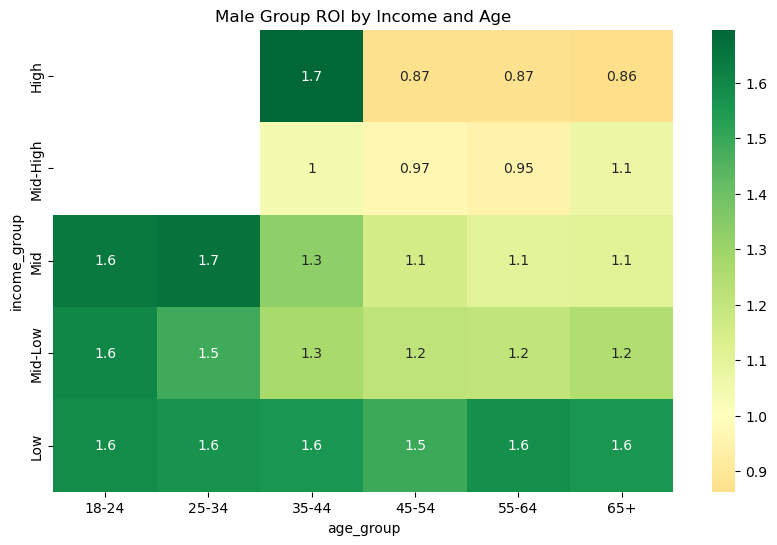

In [15]:
# 소득과 연령별로 ROI를 시각화
pivot_table = refined_analysis[refined_analysis['gender'] == 'M'].pivot(index='income_group', columns='age_group', values='ROI')
pivot_table = pivot_table.reindex(index=income_order) # 아까 만든 순서 적용

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, cmap='RdYlGn', center=1.0)
plt.title('Male Group ROI by Income and Age')
plt.show()

## 6. 세그먼트별 ROI 분석

**핵심 발견:**  
고소득층일수록 오퍼 없이도 고가 커피를 마심  
→ Cannibalization Rate 높음 → 리워드 낭비가 집중되는 구조

```
소득 ↑  →  Cannibalization Rate ↑  →  ROI ↓
소득 ↓  →  Cannibalization Rate ↓  →  ROI ↑ (오퍼가 실제 방문 유도)
```

---

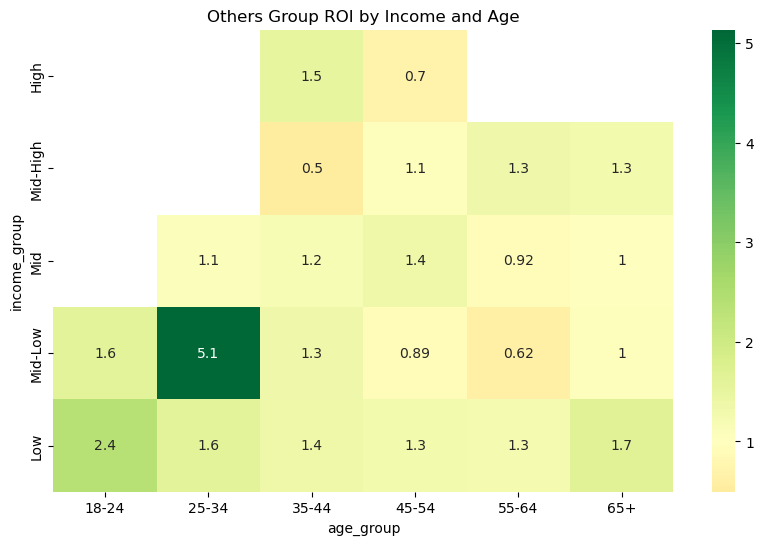

In [16]:
# 소득과 연령별로 ROI를 시각화
pivot_table = refined_analysis[refined_analysis['gender'] == 'O'].pivot(index='income_group', columns='age_group', values='ROI')
pivot_table = pivot_table.reindex(index=income_order) # 아까 만든 순서 적용

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, cmap='RdYlGn', center=1.0)
plt.title('Others Group ROI by Income and Age')
plt.show()

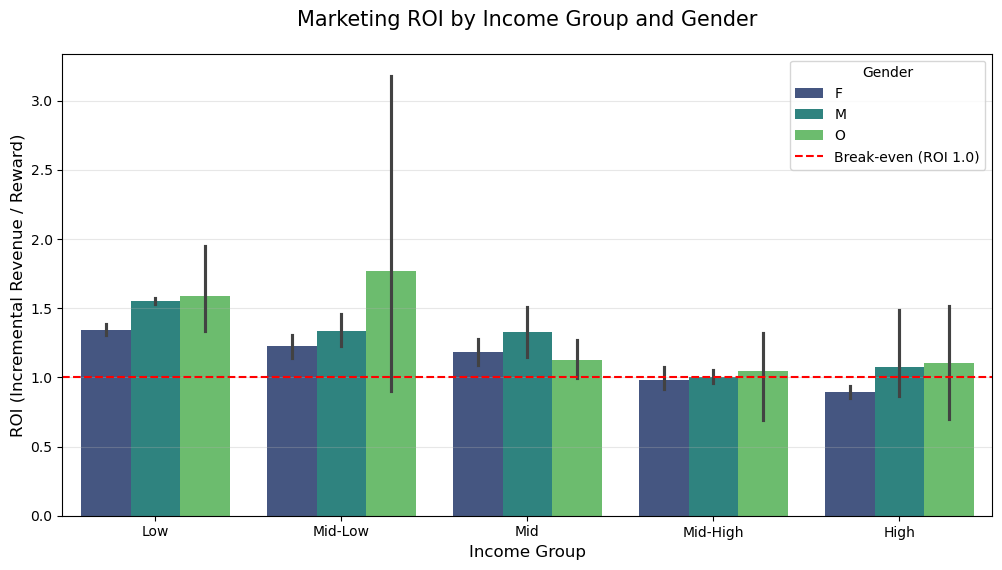

In [17]:
#시각화용 데이터 
plot_data = refined_analysis.copy()
income_order = ['Low', 'Mid-Low', 'Mid', 'Mid-High', 'High']
plot_data['income_group'] = pd.Categorical(plot_data['income_group'], categories=income_order, ordered=True)

# 그래프 
plt.figure(figsize=(12, 6))
sns.barplot(data=plot_data, x='income_group', y='ROI', hue='gender', palette='viridis')

# 시각화
plt.axhline(1.0, color='red', linestyle='--', label='Break-even (ROI 1.0)') # 손익분기선
plt.title('Marketing ROI by Income Group and Gender', fontsize=15, pad=20)
plt.ylabel('ROI (Incremental Revenue / Reward)', fontsize=12)
plt.xlabel('Income Group', fontsize=12)
plt.legend(title='Gender')
plt.grid(axis='y', alpha=0.3)

plt.show()

In [18]:
# ROI가 가장 높게 나온 베스트 타겟 그룹
# 세분화 데이터(refined_analysis) 사용
# ROI는 높을수록 좋고, 잠식 비중: 낮을수록 마케팅 기여 높음
# 가중치나 필터를 적용해 베스트 그룹 선정
# 조건: ROI가 1.2 이상이고 샘플이 어느 정도 있는 그룹
best_targets = refined_analysis[refined_analysis['ROI'] > 1.0].copy()

# 효율 점수 계산 (ROI가 높고 잠식이 낮을수록 점수 상승)
best_targets['efficiency_score'] = best_targets['ROI'] * (100 - best_targets['cannibal_rate'])

# 점수 순으로 정렬하여 TOP 5 추출
top_10_groups = best_targets.sort_values('efficiency_score', ascending=False).head(10)

print("--- 스타벅스 마케팅 '베스트 타겟' TOP 10 ---")
display(top_10_groups[['efficiency_score','income_group', 'gender', 'age_group', 'ROI', 'cannibal_rate']])



--- 스타벅스 마케팅 '베스트 타겟' TOP 10 ---


,efficiency_score,income_group,gender,age_group,ROI,cannibal_rate
22,136.303460,Low,O,18-24,2.396083,43.114057
71,113.900223,Mid-Low,O,25-34,5.131667,77.804438
27,81.662769,Low,O,65+,1.666916,51.009671
23,63.586395,Low,O,25-34,1.598005,60.208888
20,61.577446,Low,M,55-64,1.576961,60.951819
17,60.263165,Low,M,25-34,1.567662,61.558581
16,60.081852,Low,M,18-24,1.586623,62.132239
21,60.026911,Low,M,65+,1.557587,61.461602
18,60.002447,Low,M,35-44,1.553404,61.373579
64,57.836628,Mid-Low,M,18-24,1.602147,63.900545


In [19]:
# 그룹별 샘플 사이즈(행동 건수) 계산
group_counts = df.groupby(['income_group', 'gender', 'age_group']).size().reset_index(name='sample_size')

# 분석 데이터와 샘플 사이즈 합치기 
refined_analysis = refined_analysis.merge(group_counts, on=['income_group', 'gender', 'age_group'], how='left')

# 효율 점수(Efficiency Score) 다시 계산 
# ROI가 높고, 잠식률(cannibal_rate)이 낮을수록 높은 점수
refined_analysis['efficiency_score'] = refined_analysis['ROI'] * (100 - refined_analysis['cannibal_rate'])

#신뢰할 수 있는 데이터만 필터링 
reliable_targets = refined_analysis[refined_analysis['sample_size'] >= 1000].copy() 

# 5. 최종 TOP 10 추출
top_10_reliable = reliable_targets.sort_values('efficiency_score', ascending=False).head(10)

print("--- 신뢰도 기반 베스트 타겟 TOP 10 ---")
display(top_10_reliable[['efficiency_score','income_group', 'gender', 'age_group', 'ROI', 'cannibal_rate', 'sample_size']])

--- 신뢰도 기반 베스트 타겟 TOP 10 ---


,efficiency_score,income_group,gender,age_group,ROI,cannibal_rate,sample_size
20,61.577446,Low,M,55-64,1.576961,60.951819,8238
17,60.263165,Low,M,25-34,1.567662,61.558581,8480
16,60.081852,Low,M,18-24,1.586623,62.132239,6325
21,60.026911,Low,M,65+,1.557587,61.461602,9509
18,60.002447,Low,M,35-44,1.553404,61.373579,8334
64,57.836628,Mid-Low,M,18-24,1.602147,63.900545,3406
19,56.730506,Low,M,45-54,1.490125,61.929028,8610
35,51.615096,Mid,M,25-34,1.662846,68.959781,3790
34,51.489776,Mid,M,18-24,1.641167,68.626118,2124
10,49.004715,Low,F,18-24,1.455120,66.322555,2369


In [20]:
# 한명이 여러번 했을 가능성 고려 -> 인당으로도 확인 

# 사람(person)별 실적 집계 (중복 구매를 인당으로 합산)
user_level_stats = df.groupby(['person', 'income_group', 'gender', 'age_group']).agg({
    'incremental_amount': 'sum', # 한 사람이 오퍼로 벌어다 준 순수 증대 매출 합계
    'reward': 'sum'              # 한 사람이 받은 총 리워드 합계
}).reset_index()

# 인당 ROI 계산
user_level_stats['user_roi'] = user_level_stats['incremental_amount'] / user_level_stats['reward'].replace(0, np.nan)

# 그룹별(소득/성별/나이)로 인당 평균 지표 및 '사람 수' 계산
person_analysis = user_level_stats.groupby(['income_group', 'gender', 'age_group']).agg({
    'user_roi': 'mean',           # 그룹 내 사람들의 평균 ROI
    'person': 'count',            # ★ 중복 제외한 '사람 수' (Unique Users)
    'incremental_amount': 'mean'  # 인당 평균 기여 매출액
}).rename(columns={'person': 'user_count'}).reset_index()

# 기존에 계산해둔 cannibal_rate(잠식률) 병합 
if 'cannibal_rate' in refined_analysis.columns:
    person_analysis = pd.merge(
        person_analysis, 
        refined_analysis[['income_group', 'gender', 'age_group', 'cannibal_rate']], 
        on=['income_group', 'gender', 'age_group'], 
        how='left'
    )

# 최종 효율 점수 계산 (인당 ROI 기준)
person_analysis['efficiency_score'] = person_analysis['user_roi'] * (100 - person_analysis['cannibal_rate'])

# 신뢰도 필터: 고객 수(user_count)가 최소 100명 이상인 메이저 그룹만
reliable_person_targets = person_analysis[person_analysis['user_count'] >= 100].copy()

# 최종 TOP 10 추출
top_10_user_final = reliable_person_targets.sort_values('efficiency_score', ascending=False).head(10)

print("="*85)
print(" 우량 고객 TOP 10 (Unique Users 100+)  ")
print("="*85)
display(top_10_user_final[['efficiency_score', 'income_group', 'gender', 'age_group', 
                           'user_roi', 'cannibal_rate', 'user_count', 'incremental_amount']])

 우량 고객 TOP 10 (Unique Users 100+)  


,efficiency_score,income_group,gender,age_group,user_roi,cannibal_rate,user_count,incremental_amount
20,79.129444,Low,M,55-64,2.026457,60.951819,450,9.654504
18,76.942857,Low,M,35-44,1.991975,61.373579,441,10.035485
17,76.409152,Low,M,25-34,1.987678,61.558581,444,9.882628
16,74.205000,Low,M,18-24,1.959582,62.132239,336,9.944725
21,73.575804,Low,M,65+,1.909156,61.461602,512,9.412450
19,70.046066,Low,M,45-54,1.839881,61.929028,465,9.411821
10,68.830077,Low,F,18-24,2.043803,66.322555,112,14.226394
64,68.115169,Mid-Low,M,18-24,1.886875,63.900545,183,10.418332
34,67.201515,Mid,M,18-24,2.141957,68.626118,110,12.308752
65,60.974098,Mid-Low,M,25-34,1.865943,67.322643,311,11.261057


In [21]:
# 인당 누적 실적 및 반복 반응 횟수 집계
user_repeat_stats = df.groupby(['person', 'income_group', 'gender', 'age_group']).agg({
    'incremental_amount': 'sum',
    'reward': 'sum',
    'is_influenced': 'sum'  # ★ 한 고객이 오퍼에 반응해 구매한 총 횟수 (반복성)
}).reset_index()

# 인당 ROI 계산
user_repeat_stats['user_roi'] = user_repeat_stats['incremental_amount'] / user_repeat_stats['reward'].replace(0, np.nan)

# 그룹별 평균 지표 계산
group_final = user_repeat_stats.groupby(['income_group', 'gender', 'age_group']).agg({
    'user_roi': 'mean',
    'incremental_amount': 'mean',
    'is_influenced': 'mean',  # 그룹별 인당 평균 반응 횟수
    'person': 'count'
}).rename(columns={'person': 'user_count'}).reset_index()

# 잠식률 병합 및 효율 점수 계산
group_final = pd.merge(group_final, refined_analysis[['income_group', 'gender', 'age_group', 'cannibal_rate']], on=['income_group', 'gender', 'age_group'], how='left')

# 충성도 점수 (반복 횟수가 많을수록 가점)
# 단순히 한 번의 ROI가 아니라, 얼마나 자주 돈을 벌어다 줬는지를 점수에 반영
group_final['loyalty_score'] = group_final['user_roi'] * group_final['is_influenced'] * (100 - group_final['cannibal_rate'])

# 신뢰도 필터링 (사용자 100명 이상) 및 TOP 10
top_10_loyalty = group_final[group_final['user_count'] >= 100].sort_values('loyalty_score', ascending=False).head(60)

print("--- [반복 구매 반영] 진짜 VIP TOP 10 ---")
display(top_10_loyalty[['income_group', 'gender', 'age_group', 'is_influenced', 'user_roi', 'cannibal_rate', 'user_count', 'loyalty_score']])

--- [반복 구매 반영] 진짜 VIP TOP 10 ---


,income_group,gender,age_group,is_influenced,user_roi,cannibal_rate,user_count,loyalty_score
10,Low,F,18-24,10.348214,2.043803,66.322555,112,712.268384
17,Low,M,25-34,9.139640,1.987678,61.558581,444,698.352118
18,Low,M,35-44,8.907029,1.991975,61.373579,441,685.332300
16,Low,M,18-24,9.041667,1.959582,62.132239,336,670.936877
20,Low,M,55-64,8.451111,2.026457,60.951819,450,668.731724
21,Low,M,65+,8.699219,1.909156,61.461602,512,640.052014
19,Low,M,45-54,8.600000,1.839881,61.929028,465,602.396168
34,Mid,M,18-24,8.927273,2.141957,68.626118,110,599.926255
64,Mid-Low,M,18-24,8.775956,1.886875,63.900545,183,597.775743
11,Low,F,25-34,9.883598,1.794053,67.206451,189,581.485448


In [22]:
# 전체 데이터의 평균 잠식률 계산
avg_cannibal_rate = refined_analysis['cannibal_rate'].mean()
print(f"전체 평균 잠식률: {avg_cannibal_rate:.2f}%")

# 평균보다 잠식률이 낮은 '상대적 효자 그룹' 찾기 --- 샘플 사이즈 따라 달라짐
better_than_avg = refined_analysis[
    (refined_analysis['cannibal_rate'] < avg_cannibal_rate) & 
    (refined_analysis['sample_size'] >= 1000)
].sort_values('cannibal_rate')

print(f"---  평균({avg_cannibal_rate:.2f}%)보다 잠식률이 낮은 우수 타겟 ---")
display(better_than_avg[['income_group', 'gender', 'age_group', 'cannibal_rate', 'ROI', 'sample_size']].head(5))

전체 평균 잠식률: 72.65%
---  평균(72.65%)보다 잠식률이 낮은 우수 타겟 ---


,income_group,gender,age_group,cannibal_rate,ROI,sample_size
20,Low,M,55-64,60.951819,1.576961,8238
18,Low,M,35-44,61.373579,1.553404,8334
21,Low,M,65+,61.461602,1.557587,9509
17,Low,M,25-34,61.558581,1.567662,8480
19,Low,M,45-54,61.929028,1.490125,8610


In [23]:
# 실제 결제(transaction) 데이터만 추출
transactions = df[df['event'] == 'transaction'].copy()

# 활동 유형 분류
transactions['activity_type'] = transactions['is_influenced'].apply(
    lambda x: 'Coupon-Driven (쿠폰 기반)' if x == 1 else 'Pure Organic (순수 구매)'
)

# 유형별 통계 계산
activity_summary = transactions.groupby('activity_type').agg({
    'amount': ['count', 'sum', 'mean'],
    'person': 'nunique'
}).reset_index()

# 컬럼명 정리
activity_summary.columns = ['활동 유형', '결제 건수', '총 매출액', '건당 평균 결제액', '참여 고객 수']

# 매출 비중(%) 추가
total_revenue = activity_summary['총 매출액'].sum()
activity_summary['매출 비중(%)'] = (activity_summary['총 매출액'] / total_revenue) * 100

print("-"*80)
print("    [쿠폰 기반 vs 순수 구매] 마케팅 기여도 비교 분석     ")
print("-"*80)
display(activity_summary)

--------------------------------------------------------------------------------
    [쿠폰 기반 vs 순수 구매] 마케팅 기여도 비교 분석     
--------------------------------------------------------------------------------


,활동 유형,결제 건수,총 매출액,건당 평균 결제액,참여 고객 수,매출 비중(%)
0,Coupon-Driven (쿠폰 기반),111796,1370531.15,12.259215,14263,91.372036
1,Pure Organic (순수 구매),11160,129414.80,11.596308,5386,8.627964


## 7. Net Lift Index × Cannibalization Rate — 2×2 전략 매트릭스

**Net Lift Index:** (오퍼 기여 매출 - 평소 매출) / 평소 매출  
**Cannibalization Rate:** 오퍼 없이도 발생했을 매출 비율

| 사분면 | Net Lift | Cannibalization | 전략 |
|--------|----------|-----------------|------|
| A (우상) | 높음 | 낮음 | 오퍼 확대 |
| B (좌상) | 낮음 | 낮음 | 혜택 강화 |
| C (우하) | 높음 | 높음 | 오퍼 타입 변경 |
| D (좌하) | 낮음 | 높음 | **Opt-in 전환 대상** |

---

In [24]:
# 소득 그룹별로 쿠폰 기반 매출이 얼마나 차지하는지 확인
income_contribution = transactions.groupby(['income_group', 'activity_type'])['amount'].sum().unstack()
income_contribution_pct = income_contribution.div(income_contribution.sum(axis=1), axis=0) * 100

print("\n--- 소득 그룹별 매출 구성비 (쿠폰 기반 vs 순수 구매) ---")
display(income_contribution_pct)


--- 소득 그룹별 매출 구성비 (쿠폰 기반 vs 순수 구매) ---


activity_type,Coupon-Driven (쿠폰 기반),Pure Organic (순수 구매)
income_group,,
High,89.952316,10.047684
Low,90.139562,9.860438
Mid,91.615154,8.384846
Mid-High,91.636532,8.363468
Mid-Low,92.302517,7.697483


In [25]:
# 오퍼에 영향을 받은(is_influenced == 1) 결제건만 추출
influenced_tx = df[df['is_influenced'] == 1].copy()

# (오퍼 사용 시 결제액) vs (그 사람들의 평소 평균 결제액) 비교
avg_actual = influenced_tx['amount'].mean()
avg_baseline = influenced_tx['avg_baseline'].mean()

print(f"오퍼 사용자들의 실제 결제액: ${avg_actual:.2f}")
print(f"오퍼 사용자들의 평소 결제액: ${avg_baseline:.2f}")

오퍼 사용자들의 실제 결제액: $12.26
오퍼 사용자들의 평소 결제액: $12.25


In [26]:
# merged_comp 생성 — completed_events 기반
# viewed_before: True = 조회 후 완료(정상 전환), NaN = 우연완료(Accidental)
merged_comp = completed_events.copy()
merged_comp['viewed_before'] = (~merged_comp['is_accidental']).where(
    ~merged_comp['is_accidental']
)
merged_comp['event_clean'] = 'offer completed'
print(f'merged_comp shape: {merged_comp.shape}')
print(f'viewed_before NaN(우연완료): {merged_comp["viewed_before"].isna().sum()}')
print(f'viewed_before True(조회 후 완료): {merged_comp["viewed_before"].notna().sum()}')

merged_comp shape: (32444, 32)
viewed_before NaN(우연완료): 4552
viewed_before True(조회 후 완료): 27892


In [27]:
# 기초 데이터 준비
group_keys = ['gender', 'income_group', 'age_group']

# [매출 & 방문횟수] 집계
trans_stats = df[df['event'] == 'transaction'].groupby(group_keys).agg(
    visit_cnt=('event', 'count'),
    total_sales=('amount', 'sum')
).reset_index()

# [전체 오퍼 완료 건수] 집계 (분모용)
total_comp_stats = merged_comp.groupby(group_keys).size().reset_index(name='total_comp_cnt')

# [낭비된 오퍼 건수 & 리워드액] 집계 (분자용)
waste_stats = merged_comp[merged_comp['viewed_before'].isna()].groupby(group_keys).agg(
    waste_cnt=('event', 'count'),
    waste_reward_sum=('reward', 'sum')
).reset_index()

# 모든 지표 통합 (Merge 방식 사용으로 shape 불일치 해결)
report = pd.merge(trans_stats, total_comp_stats, on=group_keys, how='left')
report = pd.merge(report, waste_stats, on=group_keys, how='left')

# 유니크 인원수 추가
person_cnt = df.groupby(group_keys)['person'].nunique().reset_index(name='person_cnt')
report = pd.merge(report, person_cnt, on=group_keys, how='left')

# 결측치 0으로 채우기 (오퍼 완료가 없는 그룹 대비)
report = report.fillna(0)

# 핵심 지표 계산
# - 객단가 (평균 결제 금액)
report['avg_ticket_size'] = (report['total_sales'] / report['visit_cnt']).round(2)

# - 매출 대비 손실 비중 (%)
report['loss_on_sales'] = (report['waste_reward_sum'] / report['total_sales'] * 100).round(2)

# - 리워드 건수 낭비율 (%) : 분모와 분자를 동일한 그룹핑 데이터에서 가져옴
report['waste_ratio'] = (report['waste_cnt'] / report['total_comp_cnt'] * 100).round(2)

#  필터링 (인원수 50명 이상) 및 확인
final_report = report[report['person_cnt'] >= 50].sort_values('loss_on_sales', ascending=False)


display(final_report[['gender', 'income_group', 'age_group', 'avg_ticket_size', 'loss_on_sales', 'waste_ratio']].head(10))

,gender,income_group,age_group,avg_ticket_size,loss_on_sales,waste_ratio
34,M,Low,55-64,5.21,2.48,20.57
32,M,Low,35-44,5.15,2.34,20.59
9,F,Low,65+,7.17,2.21,17.27
33,M,Low,45-54,5.06,2.16,17.83
35,M,Low,65+,4.91,2.13,18.67
8,F,Low,55-64,7.48,2.08,16.47
30,M,Low,18-24,5.08,2.03,20.38
31,M,Low,25-34,5.04,1.91,17.79
4,F,Low,18-24,7.26,1.90,16.74
46,M,Mid-Low,18-24,5.88,1.83,18.25


In [28]:
# 고객별 유니크 인원수 계산 (Original DF 기준)
user_counts = df.groupby(['income_group', 'gender', 'age_group'])['person'].nunique().reset_index(name='user_count')

# 기존 분석 결과(refined_analysis)에서 중복될 수 있는 인원수 관련 컬럼 제거
if 'user_count' in refined_analysis.columns:
    refined_analysis = refined_analysis.drop(columns=['user_count'])
if 'sample_size' in refined_analysis.columns:
    refined_analysis = refined_analysis.drop(columns=['sample_size'])

# 효율 데이터와 인원수 데이터 병합
full_segment_report = refined_analysis.merge(user_counts, on=['income_group', 'gender', 'age_group'], how='left')

# 전체 고객 대비 비중(%) 계산
total_users_sum = full_segment_report['user_count'].sum()
full_segment_report['pop_ratio(%)'] = (full_segment_report['user_count'] / total_users_sum) * 100

# 효율 점수(efficiency_score) 기준으로 전체 정렬
full_segment_report = full_segment_report.sort_values('efficiency_score', ascending=False).reset_index(drop=True)
full_segment_report = full_segment_report[full_segment_report['user_count'] > 50]

print(f"--- 전체 세그먼트 규모 및 효율 분석 (총 {len(full_segment_report)}개 그룹) / 50명 이상 ---")
# 주요 컬럼만 순서대로 출력
display(full_segment_report[['income_group', 'gender', 'age_group', 'user_count', 'pop_ratio(%)', 'ROI', 'cannibal_rate', 'efficiency_score']])

--- 전체 세그먼트 규모 및 효율 분석 (총 49개 그룹) / 50명 이상 ---


,income_group,gender,age_group,user_count,pop_ratio(%),ROI,cannibal_rate,efficiency_score
4,Low,M,55-64,450,3.035413,1.576961,60.951819,61.577446
5,Low,M,25-34,444,2.994941,1.567662,61.558581,60.263165
6,Low,M,18-24,336,2.266442,1.586623,62.132239,60.081852
7,Low,M,65+,512,3.453626,1.557587,61.461602,60.026911
8,Low,M,35-44,441,2.974705,1.553404,61.373579,60.002447
9,Mid-Low,M,18-24,183,1.234401,1.602147,63.900545,57.836628
10,Low,M,45-54,465,3.136594,1.490125,61.929028,56.730506
12,Mid,M,25-34,200,1.349073,1.662846,68.959781,51.615096
13,Mid,M,18-24,110,0.741990,1.641167,68.626118,51.489776
14,Low,F,18-24,112,0.755481,1.455120,66.322555,49.004715


In [29]:
# 모든 세그먼트의 기본 지표를 다시 집계
full_raw_stats = df.groupby(['income_group', 'gender', 'age_group']).agg(
    user_count=('person', 'nunique'),
    total_incremental=('incremental_amount', 'sum'),
    total_reward=('reward', 'sum'),
    total_influenced_sales=('amount', lambda x: x[df.loc[x.index, 'is_influenced'] == 1].sum()),
    influenced_count=('is_influenced', 'sum')
).reset_index()

# ROI 및 잠식률 재계산 _ ROI = 순수증대매출 / 리워드비용
full_raw_stats['ROI'] = full_raw_stats['total_incremental'] / full_raw_stats['total_reward'].replace(0, np.nan)

# 잠식률 = (쿠폰매출 - 순수증대매출) / 쿠폰매출
full_raw_stats['cannibal_rate'] = (full_raw_stats['total_influenced_sales'] - full_raw_stats['total_incremental']) / full_raw_stats['total_influenced_sales'].replace(0, np.nan) * 100

# 50명 필터 적용 (전체 그룹 대상)
reliable_report = full_raw_stats[full_raw_stats['user_count'] >= 50].copy()

# 종합 효율 점수 계산 및 정렬
reliable_report['efficiency_score'] = reliable_report['ROI'] * (100 - reliable_report['cannibal_rate'])
reliable_report = reliable_report.sort_values('efficiency_score', ascending=False).reset_index(drop=True)

# 히트맵
view_final = reliable_report[['income_group', 'gender', 'age_group', 'user_count', 'ROI', 'cannibal_rate', 'efficiency_score']].round(2)

styled_final = view_final.style.background_gradient(subset=['ROI', 'efficiency_score'], cmap='YlGn') \
    .background_gradient(subset=['cannibal_rate'], cmap='OrRd') \
    .background_gradient(subset=['user_count'], cmap='PuBu')

print("--- 50명 이상 모든 세그먼트 효율 순위 ---")
# ROI와 efficiency = 진할수록 좋음
# cannibal rate = 연할수록 좋음 
display(styled_final)


--- 50명 이상 모든 세그먼트 효율 순위 ---


,income_group,gender,age_group,user_count,ROI,cannibal_rate,efficiency_score
0,Low,M,18-24,336,1.590000,78.290000,34.450000
1,Low,M,55-64,450,1.580000,78.170000,34.420000
2,Low,M,65+,512,1.560000,77.960000,34.340000
3,Low,M,25-34,444,1.570000,78.340000,33.960000
4,Low,M,35-44,441,1.550000,78.190000,33.880000
5,Low,M,45-54,465,1.490000,78.470000,32.080000
6,Mid-Low,M,18-24,183,1.600000,80.090000,31.890000
7,Mid,M,18-24,110,1.640000,81.840000,29.810000
8,Mid,M,25-34,200,1.660000,83.000000,28.280000
9,Low,F,18-24,112,1.460000,81.100000,27.500000


In [30]:
# 효율 점수 기준 하위 10개 — ROI 음수, 잠식 집중 그룹
poison_targets = reliable_report.sort_values('efficiency_score', ascending=True).head(10)

# 시각화 
view_poison = poison_targets[['income_group', 'gender', 'age_group', 'user_count', 'ROI', 'cannibal_rate', 'efficiency_score']].round(2)

styled_poison = view_poison.style.background_gradient(subset=['cannibal_rate'], cmap='Reds') \
    .background_gradient(subset=['ROI', 'efficiency_score'], cmap='RdYlGn')

print("--- 오퍼 효율이 최악인 '독'이 되는 타겟층 ---")
display(styled_poison)

--- 오퍼 효율이 최악인 '독'이 되는 타겟층 ---


,income_group,gender,age_group,user_count,ROI,cannibal_rate,efficiency_score
48,High,F,55-64,239,0.830000,90.790000,7.660000
47,High,F,65+,342,0.870000,91.020000,7.830000
46,High,M,55-64,125,0.870000,91.010000,7.840000
45,High,M,65+,150,0.860000,90.910000,7.850000
44,High,M,45-54,71,0.870000,90.790000,7.990000
43,High,F,45-54,157,0.970000,90.640000,9.040000
42,Mid-High,F,45-54,328,0.910000,90.010000,9.040000
41,Mid-High,F,55-64,444,0.950000,89.820000,9.640000
40,Mid-High,F,65+,568,0.960000,89.890000,9.660000
39,Mid-High,M,45-54,280,0.970000,89.670000,9.980000


In [31]:
# 이벤트명 표준화 및 필터링
df['event_clean'] = df['event'].str.strip().str.lower()
v_event = 'offer viewed'
c_event = 'offer completed'

#유저+오퍼별로 '확인'과 '완료' 여부 집계 (피벗)
path_analysis = df[df['event_clean'].isin([v_event, c_event])].groupby(['person', 'offer_id', 'event_clean']).size().unstack(fill_value=0).reset_index()

# 컬럼명 변경
path_analysis.rename(columns={c_event: 'completed_count', v_event: 'viewed_count'}, inplace=True)

# 타겟팅 오류 정의 (본 적 없는데 결제된 건수)
path_analysis['is_targeting_error'] = ((path_analysis['completed_count'] > 0) & (path_analysis['viewed_count'] == 0)).astype(int)

# 유저 특성 정보(소득, 성별, 연령) 결합
user_features = df[['person', 'income_group', 'gender', 'age_group']].drop_duplicates()
error_merged = path_analysis.merge(user_features, on='person', how='left')

# 세그먼트별 집계
targeting_waste_report = error_merged.groupby(['income_group', 'gender', 'age_group']).agg(
    total_completions=('completed_count', 'sum'),
    uninformed_completions=('is_targeting_error', 'sum'),
    user_count=('person', 'nunique')
).reset_index()

# 오류율(%) 계산
targeting_waste_report['error_rate(%)'] = (targeting_waste_report['uninformed_completions'] / targeting_waste_report['total_completions'].replace(0, np.nan)) * 100

# 30명 이상 신뢰 그룹 필터링 및 정렬
final_error_report = targeting_waste_report[targeting_waste_report['user_count'] >= 30].sort_values('error_rate(%)', ascending=False).reset_index(drop=True)

# 최종 결과 출력 
print("---  오퍼 확인 없이 결제된 타겟팅 오류  ---")
display(final_error_report.head(10))



---  오퍼 확인 없이 결제된 타겟팅 오류  ---


,income_group,gender,age_group,total_completions,uninformed_completions,user_count,error_rate(%)
0,High,M,65+,438,100,150,22.831050
1,High,M,55-64,366,79,124,21.584699
2,Mid-Low,F,18-24,183,39,84,21.311475
3,High,M,45-54,189,40,71,21.164021
4,High,F,65+,934,197,342,21.092077
5,High,F,45-54,425,89,156,20.941176
6,Mid,F,25-34,216,43,88,19.907407
7,High,F,55-64,681,132,239,19.383260
8,Low,F,65+,579,110,267,18.998273
9,Low,F,45-54,332,63,167,18.975904


In [32]:
# 유저별 오퍼 확인율(View Rate) 및 총 소비액(Amount) 계산
user_stats = df.groupby('person').agg(
    received_cnt=('event', lambda x: (x == 'offer received').sum()),
    viewed_cnt=('event', lambda x: (x == 'offer viewed').sum()),
    total_spend=('amount', 'sum') # transaction 이벤트의 amount 합계
).reset_index()

# 확인율 계산 (0으로 나누기 방지)
user_stats['view_rate'] = user_stats['viewed_cnt'] / user_stats['received_cnt'].replace(0, 1)

# 유저 특성 정보 결합
user_info = df[['person', 'income_group', 'gender', 'age_group']].drop_duplicates()
full_analysis = user_stats.merge(user_info, on='person', how='left')

# 세그먼트별 평균 지표 집계
segment_report = full_analysis.groupby(['income_group', 'gender', 'age_group']).agg(
    avg_view_rate=('view_rate', 'mean'),
    avg_spend=('total_spend', 'mean'),
    user_count=('person', 'count')
).reset_index()

# 필터링: 인원수 50명 이상인 그룹만 추출 _'확인율은 낮고 지출은 높은' 순서로 정렬 (평균 지출 내림차순)
view_report = segment_report[segment_report['user_count'] >= 50].sort_values('avg_spend', ascending=False).reset_index(drop=True)

#소수점 정리 및 출력
styled_report = view_report.style.background_gradient(subset=['avg_view_rate'], cmap='YlGn_r') \
    .background_gradient(subset=['avg_spend'], cmap='Greens') \
    .format({'avg_view_rate': '{:.2%}', 'avg_spend': '${:.2f}'})

print("--- 세그먼트별 오퍼 확인율 vs 소비액 (인원 50명 이상) ---")
display(styled_report)

--- 세그먼트별 오퍼 확인율 vs 소비액 (인원 50명 이상) ---


,income_group,gender,age_group,avg_view_rate,avg_spend,user_count
0,High,M,65+,66.83%,$167.41,150
1,High,M,55-64,67.37%,$165.46,125
2,Mid-High,F,35-44,96.77%,$165.18,80
3,High,F,45-54,69.97%,$155.43,157
4,Mid-High,M,65+,81.73%,$152.51,406
5,High,M,45-54,63.80%,$150.67,71
6,High,F,65+,67.18%,$149.88,342
7,Mid-High,F,65+,76.16%,$149.44,568
8,High,F,55-64,67.52%,$149.35,239
9,Mid-High,F,55-64,75.10%,$147.62,444


In [33]:
# view_report를 사용
# 확인율(avg_view_rate) 기준으로 오름차순(낮은 순) 정렬
# 지출액(avg_spend) 기준으로 내림차순(높은 순) 정렬
loyal_but_ignorant = view_report.sort_values(by=['avg_view_rate', 'avg_spend'], 
                                              ascending=[True, False])

# 확인율 하위 25% 지점 계산 (상대적 하위 그룹 찾기)
view_threshold = loyal_but_ignorant['avg_view_rate'].quantile(0.25)

# 확인율은 상대적으로 낮으면서(하위 25%), 지출은 평균보다 높은 그룹 필터링
avg_spend_total = loyal_but_ignorant['avg_spend'].mean()
target_groups = loyal_but_ignorant[
    (loyal_but_ignorant['avg_view_rate'] <= view_threshold) & 
    (loyal_but_ignorant['avg_spend'] > avg_spend_total)
]

print(f"--- 상대적 _ 오퍼 무관심 그룹 (확인율 {view_threshold:.1%} 이하 & 평균 이상 지출) ---")
display(target_groups.style.background_gradient(subset=['avg_view_rate'], cmap='Reds')
                  .background_gradient(subset=['avg_spend'], cmap='Greens'))

--- 상대적 _ 오퍼 무관심 그룹 (확인율 68.8% 이하 & 평균 이상 지출) ---


,income_group,gender,age_group,avg_view_rate,avg_spend,user_count
5,High,M,45-54,0.638028,150.671268,71
0,High,M,65+,0.668333,167.408400,150
6,High,F,65+,0.671784,149.883275,342
1,High,M,55-64,0.673733,165.460000,125
8,High,F,55-64,0.675174,149.346611,239
19,Mid-Low,F,25-34,0.683721,118.943488,129


In [34]:
# 우연한 완료(타겟팅 오류) 데이터 
target_error_df = completed_events[completed_events['is_accidental'] == True].copy()

# 고소득(High) + 남성(M) + 45세 이상' 그룹 필터링
waste_group = target_error_df[
    (target_error_df['income_group'] == 'High') & 
    (target_error_df['gender'] == 'M') & 
    (target_error_df['age_group'].isin(['45-54', '55-64', '65+']))
]

# 절감액 계산
# 'reward' _ 실제 지급된 금액을 합산
total_waste_count = len(waste_group)
total_saved_amount = waste_group['reward'].sum()

print(f"--- [고소득 45+ 남성] 예산 낭비 정밀 분석 ---")
print(f"1. 해당 그룹의 '미확인 완료' 건수: {total_waste_count:,}건")
print(f"2. 이들에게 낭비된 실제 리워드 총액: ${total_saved_amount:,.2f}")
print("-" * 45)
print(f"결론: 이 그룹에 대한 오퍼 발송만 중단해도 ${total_saved_amount:,.2f}의 이익이 즉각 발생")

--- [고소득 45+ 남성] 예산 낭비 정밀 분석 ---
1. 해당 그룹의 '미확인 완료' 건수: 129건
2. 이들에게 낭비된 실제 리워드 총액: $591.00
---------------------------------------------
결론: 이 그룹에 대한 오퍼 발송만 중단해도 $591.00의 이익이 즉각 발생


In [35]:
# '오퍼 무관심 세그먼트'의 특징 추출
segments_to_cut = target_groups[['income_group', 'gender', 'age_group']]

# 전체 완료 데이터(completed_events)에서 위 세그먼트에 해당하는 데이터만 필터링
# 'is_accidental'이 True인(오퍼 안 보고 완료한) 건들만
waste_analysis_full = completed_events[
    (completed_events['is_accidental'] == True)
].merge(segments_to_cut, on=['income_group', 'gender', 'age_group'], how='inner')

# 전체 예산 낭비 수치 산출
total_waste_reward = waste_analysis_full['reward'].sum()
total_waste_count = len(waste_analysis_full)
avg_waste_per_person = total_waste_reward / waste_analysis_full['person'].nunique()

print(f"--- [전체 오퍼 무관심 세그먼트] 마케팅 최적화 리포트 ---")
print(f"1. 예산 삭감 대상 그룹 수: {len(segments_to_cut)}개 세그먼트")
print(f"2. 해당 그룹 내 '우연한 완료' 총 횟수: {total_waste_count:,}건")
print(f"3. 낭비되고 있는 리워드 총액: ${total_waste_reward:,.2f}")
print(f"4. 대상 인원 1인당 평균 낭비 예산: ${avg_waste_per_person:,.2f}")

--- [전체 오퍼 무관심 세그먼트] 마케팅 최적화 리포트 ---
1. 예산 삭감 대상 그룹 수: 6개 세그먼트
2. 해당 그룹 내 '우연한 완료' 총 횟수: 363건
3. 낭비되고 있는 리워드 총액: $1,674.00
4. 대상 인원 1인당 평균 낭비 예산: $5.17


In [36]:
# 무관심 그룹 세그먼트
segments_to_cut = target_groups[['income_group', 'gender', 'age_group']]

# 이 세그먼트 사람들에게 지급된 '모든 리워드' (completed_events 기준)
all_rewards_for_this_group = completed_events.merge(
    segments_to_cut, on=['income_group', 'gender', 'age_group'], how='inner'
)

# 그중 '우연히 완료(is_accidental)'된 낭비 예산
wasted_rewards = all_rewards_for_this_group[all_rewards_for_this_group['is_accidental'] == True]

# 비중 계산
total_given = all_rewards_for_this_group['reward'].sum()
total_wasted = wasted_rewards['reward'].sum()
waste_ratio = (total_wasted / total_given) * 100

print(f"---  오퍼 무관심 그룹 예산 정밀 진단 ---")
print(f"1. 이 그룹에 지급된 전체 리워드: ${total_given:,.2f}")
print(f"2. 그중 낭비된 리워드(미확인): ${total_wasted:,.2f}")
print(f"3. 예산 낭비 비중(Waste Ratio): {waste_ratio:.1f}%")
print("-" * 40)

---  오퍼 무관심 그룹 예산 정밀 진단 ---
1. 이 그룹에 지급된 전체 리워드: $15,205.00
2. 그중 낭비된 리워드(미확인): $1,674.00
3. 예산 낭비 비중(Waste Ratio): 11.0%
----------------------------------------


In [37]:
# 세그먼트별 전체 리워드 합계 (전체 완료 건 기준)
total_reward_by_seg = completed_events.groupby(['income_group', 'gender', 'age_group'])['reward'].sum().reset_index(name='total_reward')

# 세그먼트별 낭비된 리워드 합계 (is_accidental == True 인 건만)
wasted_reward_by_seg = completed_events[completed_events['is_accidental'] == True].groupby(
    ['income_group', 'gender', 'age_group'])['reward'].sum().reset_index(name='wasted_reward')

# 유저 수 카운트 
user_count_by_seg = completed_events.groupby(['income_group', 'gender', 'age_group'])['person'].nunique().reset_index(name='user_count')

# 데이터 하나로 합치기
segment_analysis = total_reward_by_seg.merge(wasted_reward_by_seg, on=['income_group', 'gender', 'age_group'], how='left')
segment_analysis = segment_analysis.merge(user_count_by_seg, on=['income_group', 'gender', 'age_group'], how='left')

# 결측치 처리 (낭비가 0인 그룹) 및 비중 계산
segment_analysis['wasted_reward'] = segment_analysis['wasted_reward'].fillna(0)
segment_analysis['waste_ratio'] = (segment_analysis['wasted_reward'] / segment_analysis['total_reward']) * 100

# 인원 50명 이상인 그룹만 필터링해서 낭비 비중 순으로 정렬
final_ranking = segment_analysis[segment_analysis['user_count'] >= 50].sort_values('waste_ratio', ascending=False)

print("--- 세그먼트별 예산 낭비 비중 (Waste Ratio) 최종 리포트 ---")
display(final_ranking.style.background_gradient(subset=['waste_ratio'], cmap='Reds')
                  .format({'waste_ratio': '{:.1f}%', 'total_reward': '${:,.0f}', 'wasted_reward': '${:,.0f}'}))

--- 세그먼트별 예산 낭비 비중 (Waste Ratio) 최종 리포트 ---


,income_group,gender,age_group,total_reward,wasted_reward,user_count,waste_ratio
20,Low,M,55-64,"$2,755",$547,291,19.9%
18,Low,M,35-44,"$2,849",$526,290,18.5%
15,Low,F,65+,"$2,706",$469,216,17.3%
19,Low,M,45-54,"$2,937",$492,291,16.8%
21,Low,M,65+,"$3,094",$514,313,16.6%
14,Low,F,55-64,"$1,669",$273,134,16.4%
16,Low,M,18-24,"$2,106",$342,213,16.2%
63,Mid-Low,M,18-24,"$1,190",$189,120,15.9%
10,Low,F,18-24,"$1,095",$171,90,15.6%
17,Low,M,25-34,"$2,799",$430,292,15.4%


In [38]:

# 기본 통계량 계산 (확인율, 지출액, 유저수)
segment_base = loyal_but_ignorant[['income_group', 'gender', 'age_group', 'avg_view_rate', 'avg_spend', 'user_count']]

#  segment_analysis(낭비 비중 데이터)와 결합
combined_report = segment_base.merge(
    segment_analysis[['income_group', 'gender', 'age_group', 'waste_ratio', 'total_reward']], 
    on=['income_group', 'gender', 'age_group'], 
    how='inner'
)

# 정렬 (확인율은 낮고, 낭비 비중은 높은 순)
# 오퍼 미확인 상태로 리워드를 수령하는 C유형 — 마케팅 기여 없음
strategic_report = combined_report.sort_values(by=['avg_view_rate', 'waste_ratio'], ascending=[True, False])

print("--- 오퍼 확인율 + 예산 낭비 비중 ---")
display(strategic_report.style.background_gradient(subset=['avg_view_rate'], cmap='RdYlGn')
                  .background_gradient(subset=['waste_ratio'], cmap='OrRd')
                  .format({'avg_view_rate': '{:.1%}', 'waste_ratio': '{:.1%}', 'avg_spend': '${:.2f}'}))

--- 오퍼 확인율 + 예산 낭비 비중 ---


,income_group,gender,age_group,avg_view_rate,avg_spend,user_count,waste_ratio,total_reward
0,High,M,45-54,63.8%,$150.67,71,1051.1%,1018
1,Low,M,45-54,66.3%,$48.93,465,1675.2%,2937
2,High,M,65+,66.8%,$167.41,150,1055.8%,2330
3,Low,M,35-44,67.2%,$50.91,441,1846.3%,2849
4,High,F,65+,67.2%,$149.88,342,1026.8%,4743
5,High,M,55-64,67.4%,$165.46,125,1236.4%,1925
6,Mid,M,18-24,67.4%,$76.47,110,1454.5%,825
7,High,F,55-64,67.5%,$149.35,239,1210.6%,3552
8,Low,M,55-64,67.6%,$49.07,450,1985.5%,2755
9,Low,M,25-34,67.9%,$50.82,444,1536.3%,2799


In [39]:
# 오퍼 확인율이 높다고 성공적인 캠페인 아님.
# 확인율이 높고 + 낭비 비중 높으면 = 마케팅이 매출 증대에 기여하지 못함 
# 확인율 낮고 + 낭비 비중 높으면 = 채널 도달 자체가 실패한 케이스 

In [40]:
# 마케팅 예산 집행의 정확도 


# [마케팅 비용 낭비율]'전체 리워드 예산' 대비 '낭비된 리워드'의 비중 계산

# segment_analysis 테이블
segment_analysis['marketing_efficiency_loss'] = (segment_analysis['wasted_reward'] / segment_analysis['total_reward']) * 100

# 확인율과 결합하여 출력
final_insight = segment_analysis.merge(segment_base, on=['income_group', 'gender', 'age_group'])

# '마케팅 효율 손실'이 크고 '확인율'은 낮은 그룹
top_inefficient = final_insight.sort_values('marketing_efficiency_loss', ascending=False)

display(top_inefficient[['income_group', 'gender', 'age_group', 'avg_view_rate', 'marketing_efficiency_loss', 'total_reward']].head(30))



,income_group,gender,age_group,avg_view_rate,marketing_efficiency_loss,total_reward
16,Low,M,55-64,0.675593,19.854809,2755
14,Low,M,35-44,0.671693,18.462618,2849
11,Low,F,65+,0.700738,17.331855,2706
15,Low,M,45-54,0.663477,16.751788,2937
17,Low,M,65+,0.688216,16.612799,3094
10,Low,F,55-64,0.706145,16.357100,1669
12,Low,M,18-24,0.699454,16.239316,2106
43,Mid-Low,M,18-24,0.682514,15.882353,1190
6,Low,F,18-24,0.733036,15.616438,1095
13,Low,M,25-34,0.678941,15.362630,2799


In [41]:
# 리워드가 있는 오퍼만 필터링해서 분석
actual_money_waste = completed_events[completed_events['reward'] > 0]

# 리워드가 0인 건들은 별도로 '정보성 오퍼'로 분류-이들은 예산 낭비보다는 단순 마케팅 노이즈


In [42]:
# 낭비 비중이 10% 미만인 효율적인 그룹만 추출
efficient_groups = final_ranking[final_ranking['waste_ratio'] < 10].sort_values('waste_ratio')

print(f"--- 마케팅 효율 좋은 그룹 (Waste Ratio < 10%) ---")
if len(efficient_groups) > 0:
    display(efficient_groups.style.background_gradient(subset=['waste_ratio'], cmap='Greens')
                      .format({'waste_ratio': '{:.1f}%', 'total_reward': '${:,.0f}', 'wasted_reward': '${:,.0f}'}))
else:
    print("모든 그룹의 낭비 비중이 10% 이상입니다. 전체적인 타겟팅 조정이 필요할 수 있습니다.")

--- 마케팅 효율 좋은 그룹 (Waste Ratio < 10%) ---


,income_group,gender,age_group,total_reward,wasted_reward,user_count,waste_ratio
45,Mid-High,F,35-44,"$1,169",$83,72,7.1%
49,Mid-High,M,35-44,"$1,661",$158,106,9.5%


In [43]:
# 50명 이상 세그먼트 전체의 평균 지표 산출
baseline = report[['person_cnt', 'total_sales', 'waste_reward_sum', 'loss_on_sales', 'waste_ratio']].mean()

print("[Base Line] 50명 이상 세그먼트 전체 평균값")
print("-" * 50)
print(f"인원수 평균 (person_cnt)        : {baseline['person_cnt']:.1f}명")
print(f"세그먼트당 매출 평균 (total_sales): ${baseline['total_sales']:,.2f}")
print(f"리워드 낭비액 평균 (waste_reward): ${baseline['waste_reward_sum']:,.2f}")
print(f"매출 대비 손실 비중 (loss_on_sales): {baseline['loss_on_sales']:.2f}%")
print(f"리워드 건수 낭비율 (waste_ratio)  : {baseline['waste_ratio']:.2f}%")
print("-" * 50)

[Base Line] 50명 이상 세그먼트 전체 평균값
--------------------------------------------------
인원수 평균 (person_cnt)        : 195.1명
세그먼트당 매출 평균 (total_sales): $19,736.13
리워드 낭비액 평균 (waste_reward): $269.80
매출 대비 손실 비중 (loss_on_sales): 1.29%
리워드 건수 낭비율 (waste_ratio)  : 12.74%
--------------------------------------------------


In [44]:
# 매출 대비 손실 비중에 집중해야함 
# 우리는 영업 이익과 비교해야함. 5천원 판다고 5천원 다 남는게 아니기 때문 
# 보통 영업 이익률 10~15%임 (스타벅스 = 15%임) = 1만원 팔아서 1500 남기기

# 매출 대비 손실액 1.56% = 1만원 팔아 156원 손실이지만, 이익 대비로 보았을 때 10.4% (순이익 10% 마케팅으로 날림)
# 임계점 = 1.56% (이것보다 높으면 손해임)

# 마케팅은 비용이 아니라 투자임. (원래는 1투자했을 때 2가져오는게 목표)
# 매출 대비 손실액이 2.47% = 손실률 16.47인데, 그렇다면 가만히 있어도 1500원 벌을거 1253원 번다는 것 
# 연간 영업이익이 1조면, 이익 16.47% 차이는 1,647억원임 (이 비율 반절만 줄여도 800억원 순이익 추가로 생김)

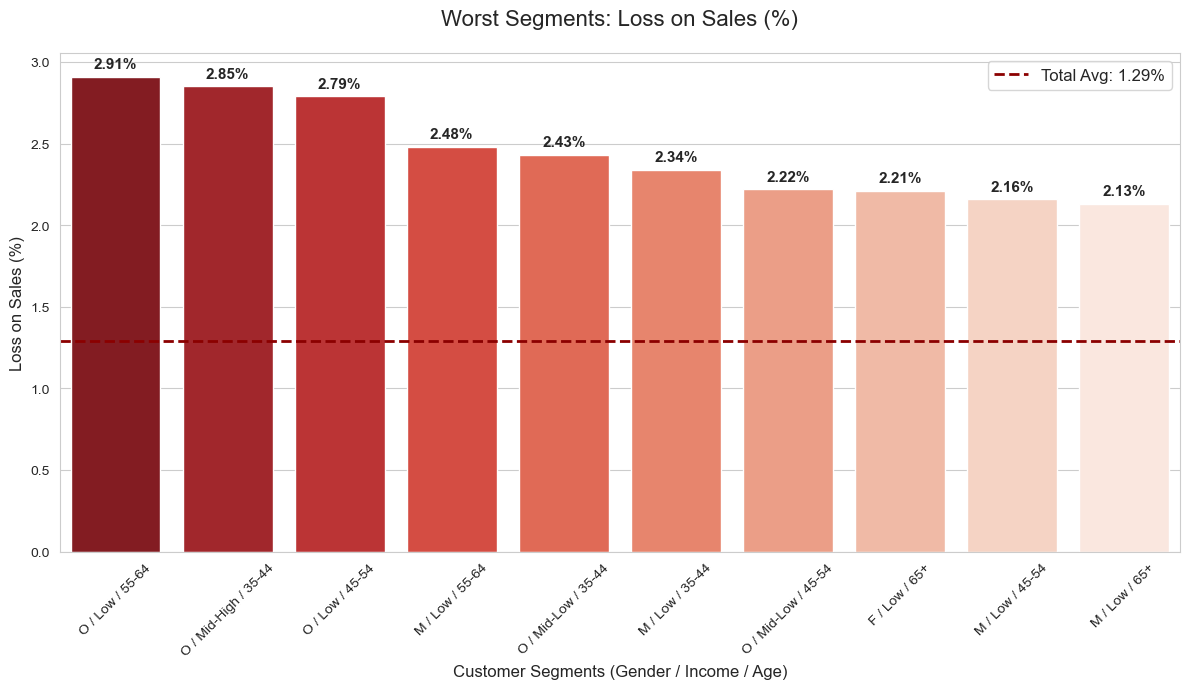

In [45]:
# 시각화용 데이터 준비 (Worst 10 추출)
worst_10 = report.sort_values('loss_on_sales', ascending=False).head(10).copy()

# 세그먼트 이름 가독성 있게 만들기 (예: M / Low / 18-24)
worst_10['segment_name'] = (worst_10['gender'] + " / " + 
                             worst_10['income_group'] + " / " + 
                             worst_10['age_group'])

# 전체 평균 계산 (Base Line)
avg_loss = report['loss_on_sales'].mean()

# 차트 그리기
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# 막대 그래프 (Worst 10)
colors = sns.color_palette("Reds_r", 10)
barplot = sns.barplot(x='segment_name', y='loss_on_sales', data=worst_10, palette=colors)

# 전체 평균 가이드라인 (빨간 점선)
plt.axhline(avg_loss, color='darkred', linestyle='--', linewidth=2, label=f'Total Avg: {avg_loss:.2f}%')

# 차트 디테일 설정
plt.title('Worst Segments: Loss on Sales (%)', fontsize=16, pad=20)
plt.ylabel('Loss on Sales (%)', fontsize=12)
plt.xlabel('Customer Segments (Gender / Income / Age)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(fontsize=12)

# 값 표시 (막대 위에 % 수치 적기)
for p in barplot.patches:
    barplot.annotate(format(p.get_height(), '.2f') + '%', 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points',
                   fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

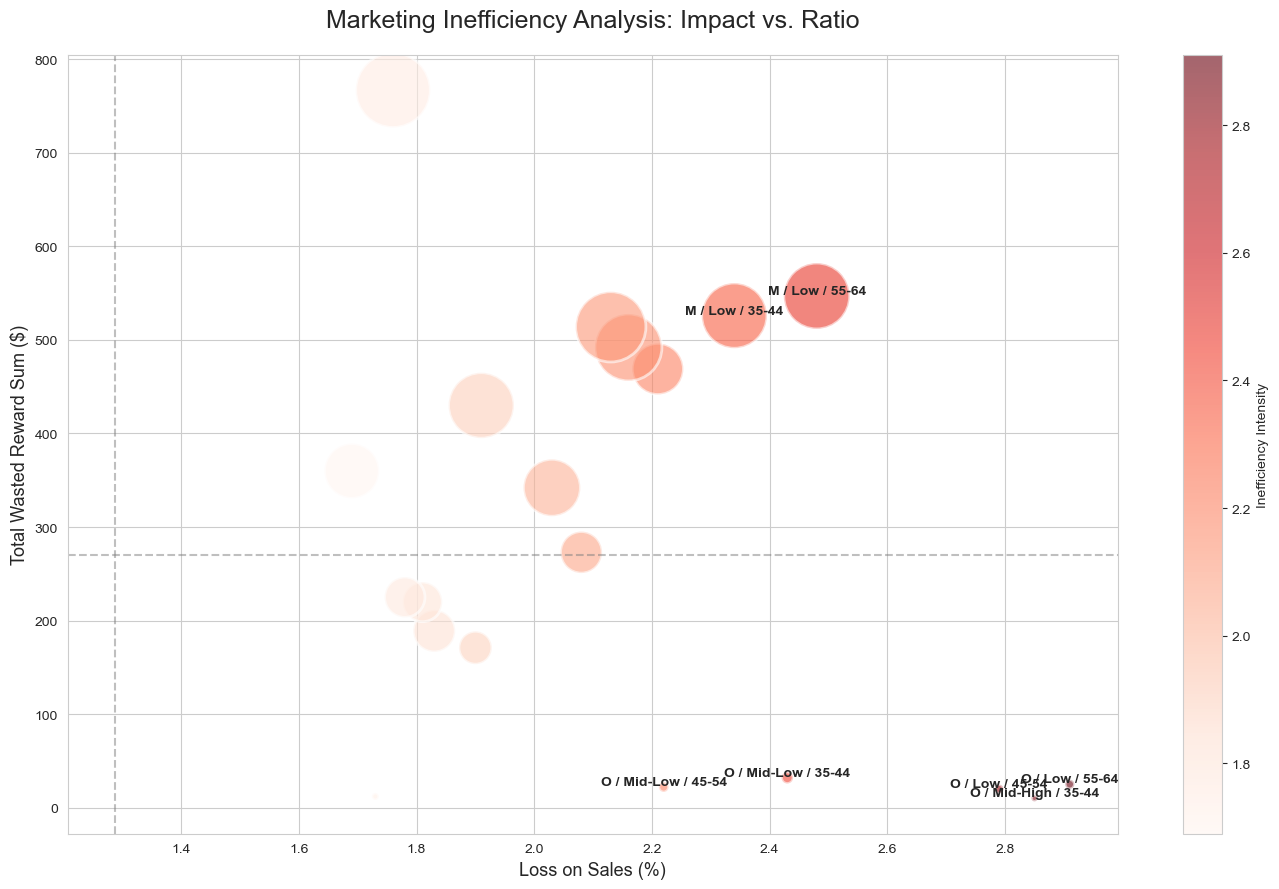

In [46]:
# 시각화 데이터 준비 
bubble_data = report.sort_values('loss_on_sales', ascending=False).head(20).copy()
bubble_data['segment_name'] = (bubble_data['gender'] + " / " + 
                                bubble_data['income_group'] + " / " + 
                                bubble_data['age_group'])

# 버블 차트
plt.figure(figsize=(14, 9))
sns.set_style("whitegrid")

# scatter plot 생성
scatter = plt.scatter(
    x=bubble_data['loss_on_sales'], 
    y=bubble_data['waste_reward_sum'], 
    s=bubble_data['person_cnt'] * 5,  # 원의 크기 조절
    c=bubble_data['loss_on_sales'],   # 색상 기준
    cmap='Reds', 
    alpha=0.6, 
    edgecolors="w", 
    linewidth=2
)

# 주요 세그먼트 이름 표시 (상위 7개만)
for i in range(7):
    plt.text(
        bubble_data.iloc[i]['loss_on_sales'], 
        bubble_data.iloc[i]['waste_reward_sum'] + 2, # 텍스트 위치 살짝 위로
        bubble_data.iloc[i]['segment_name'], 
        fontsize=10, 
        fontweight='bold',
        ha='center'
    )

# 전체 평균 가이드라인
plt.axvline(report['loss_on_sales'].mean(), color='grey', linestyle='--', alpha=0.5)
plt.axhline(report['waste_reward_sum'].mean(), color='grey', linestyle='--', alpha=0.5)

# 차트 디테일
plt.title('Marketing Inefficiency Analysis: Impact vs. Ratio', fontsize=18, pad=20)
plt.xlabel('Loss on Sales (%)', fontsize=13)
plt.ylabel('Total Wasted Reward Sum ($)', fontsize=13)
plt.colorbar(label='Inefficiency Intensity')

plt.tight_layout()
plt.show()

In [47]:
# 영업이익률 15% 가정 하에 이익 대비 손실률 계산
report['loss_on_profit'] = (report['loss_on_sales'] / 15 * 100).round(2)

# Best(효율)와 Worst(비효율) 추출
best_3 = report.sort_values('loss_on_profit', ascending=True).head(3)
worst_3 = report.sort_values('loss_on_profit', ascending=False).head(3)

# 비교 데이터프레임 생성
comparison = pd.concat([best_3, worst_3])
comparison['status'] = ['Best(Efficient)']*3 + ['Worst(Inefficient)']*3

# 가독성을 위한 컬럼 선택
display_cols = ['status', 'gender', 'income_group', 'age_group', 'loss_on_sales', 'loss_on_profit', 'waste_ratio']
print("효율 그룹 vs 비효율 그룹 비교")
display(comparison[display_cols])

효율 그룹 vs 비효율 그룹 비교


,status,gender,income_group,age_group,loss_on_sales,loss_on_profit,waste_ratio
71,Best(Efficient),O,Mid-Low,25-34,0.00,0.0,0.00
62,Best(Efficient),O,Mid,35-44,0.00,0.0,0.00
60,Best(Efficient),O,Mid,18-24,0.00,0.0,NaN
58,Worst(Inefficient),O,Low,55-64,2.91,19.4,14.81
66,Worst(Inefficient),O,Mid-High,35-44,2.85,19.0,11.11
57,Worst(Inefficient),O,Low,45-54,2.79,18.6,22.22


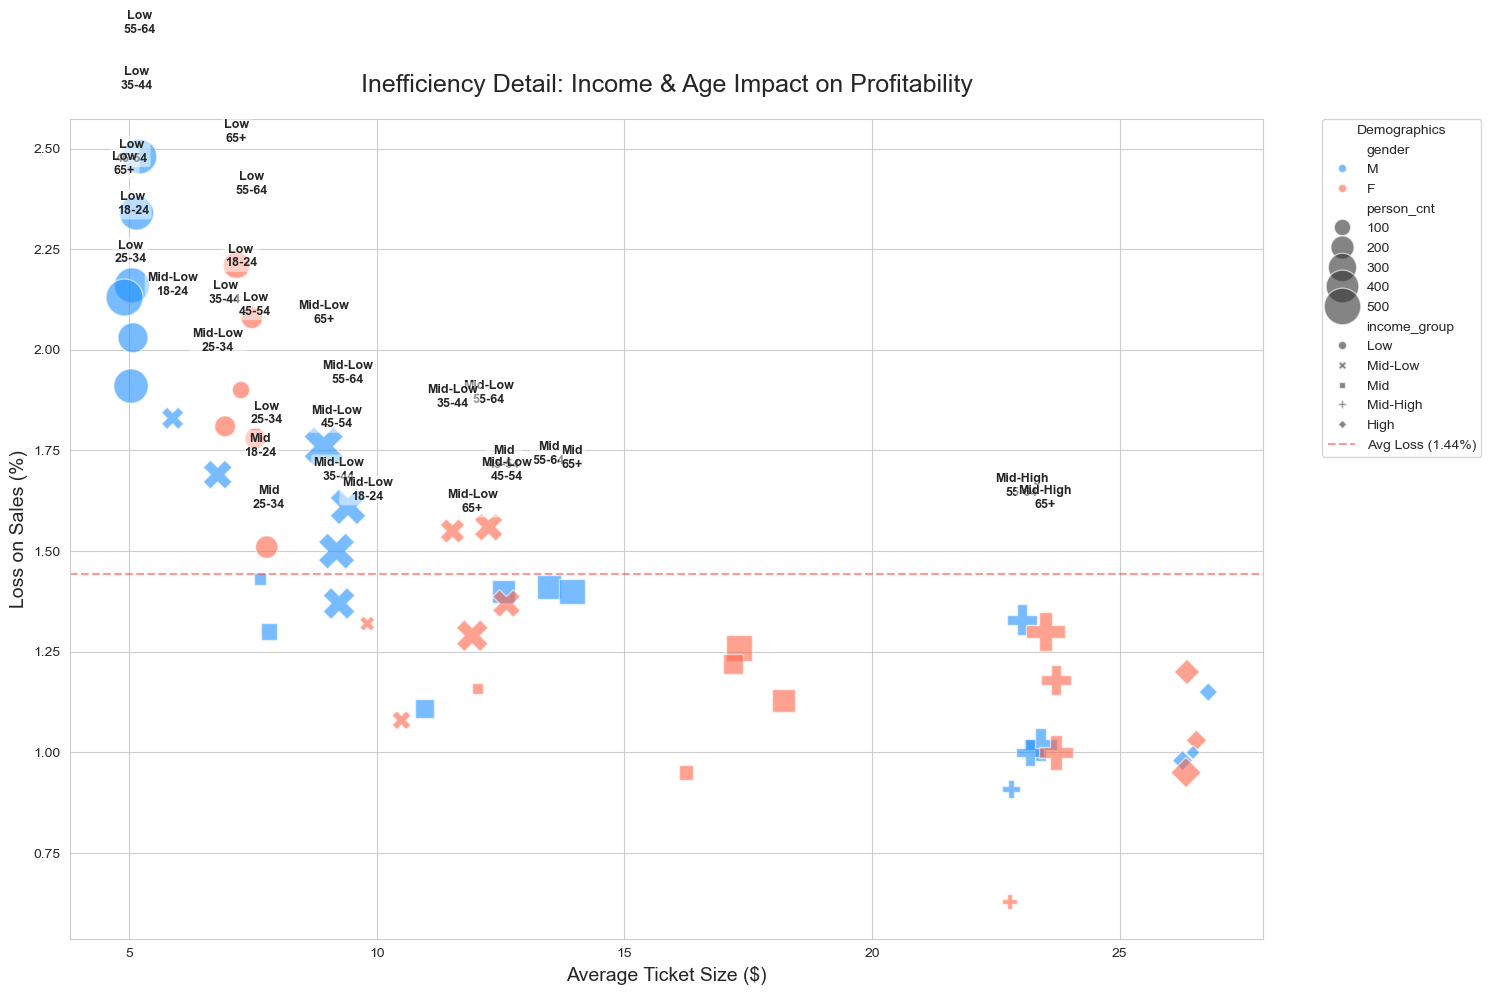

In [48]:
# 시각화 스타일 설정 
plt.figure(figsize=(15, 10))
sns.set_style("whitegrid")
plt.rc('font', family='sans-serif') 

# 산점도 그리기
# 색상은 성별(gender), 모양은 소득그룹(income_group), 크기는 인원수(person_cnt)
scatter = sns.scatterplot(
    data=final_report, 
    x='avg_ticket_size', 
    y='loss_on_sales', 
    hue='gender',
    style='income_group', # 소득 그룹별로 점 모양 변경
    size='person_cnt',
    sizes=(100, 800),
    alpha=0.6,
    palette={'M': 'dodgerblue', 'F': 'tomato', 'O': 'green'}
)

# 상세 레이블 추가 (손실률 상위 15개 세그먼트 표시)
top_segments = final_report.sort_values('loss_on_sales', ascending=False).head(30)

for i in range(len(top_segments)):
    # 예: "Mid-High / 30s" 형태의 영문 레이블 생성
    label = f"{top_segments.iloc[i]['income_group']}\n{top_segments.iloc[i]['age_group']}"
    plt.text(
        top_segments.iloc[i]['avg_ticket_size'], 
        top_segments.iloc[i]['loss_on_sales'] + 0.3, # 텍스트 위치 살짝 위로
        label,
        fontsize=9,
        ha='center',
        va='bottom',
        fontweight='bold',
        bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', boxstyle='round,pad=0.2')
    )

# 가이드라인 및 서식 
avg_loss = final_report['loss_on_sales'].mean()
plt.axhline(avg_loss, color='red', linestyle='--', alpha=0.4, label=f'Avg Loss ({avg_loss:.2f}%)')

plt.title('Inefficiency Detail: Income & Age Impact on Profitability', fontsize=18, pad=20)
plt.xlabel('Average Ticket Size ($)', fontsize=14)
plt.ylabel('Loss on Sales (%)', fontsize=14)

# 범례 정리 (성별, 소득, 인원수 정보 포함)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., title="Demographics")

plt.tight_layout()
plt.show()

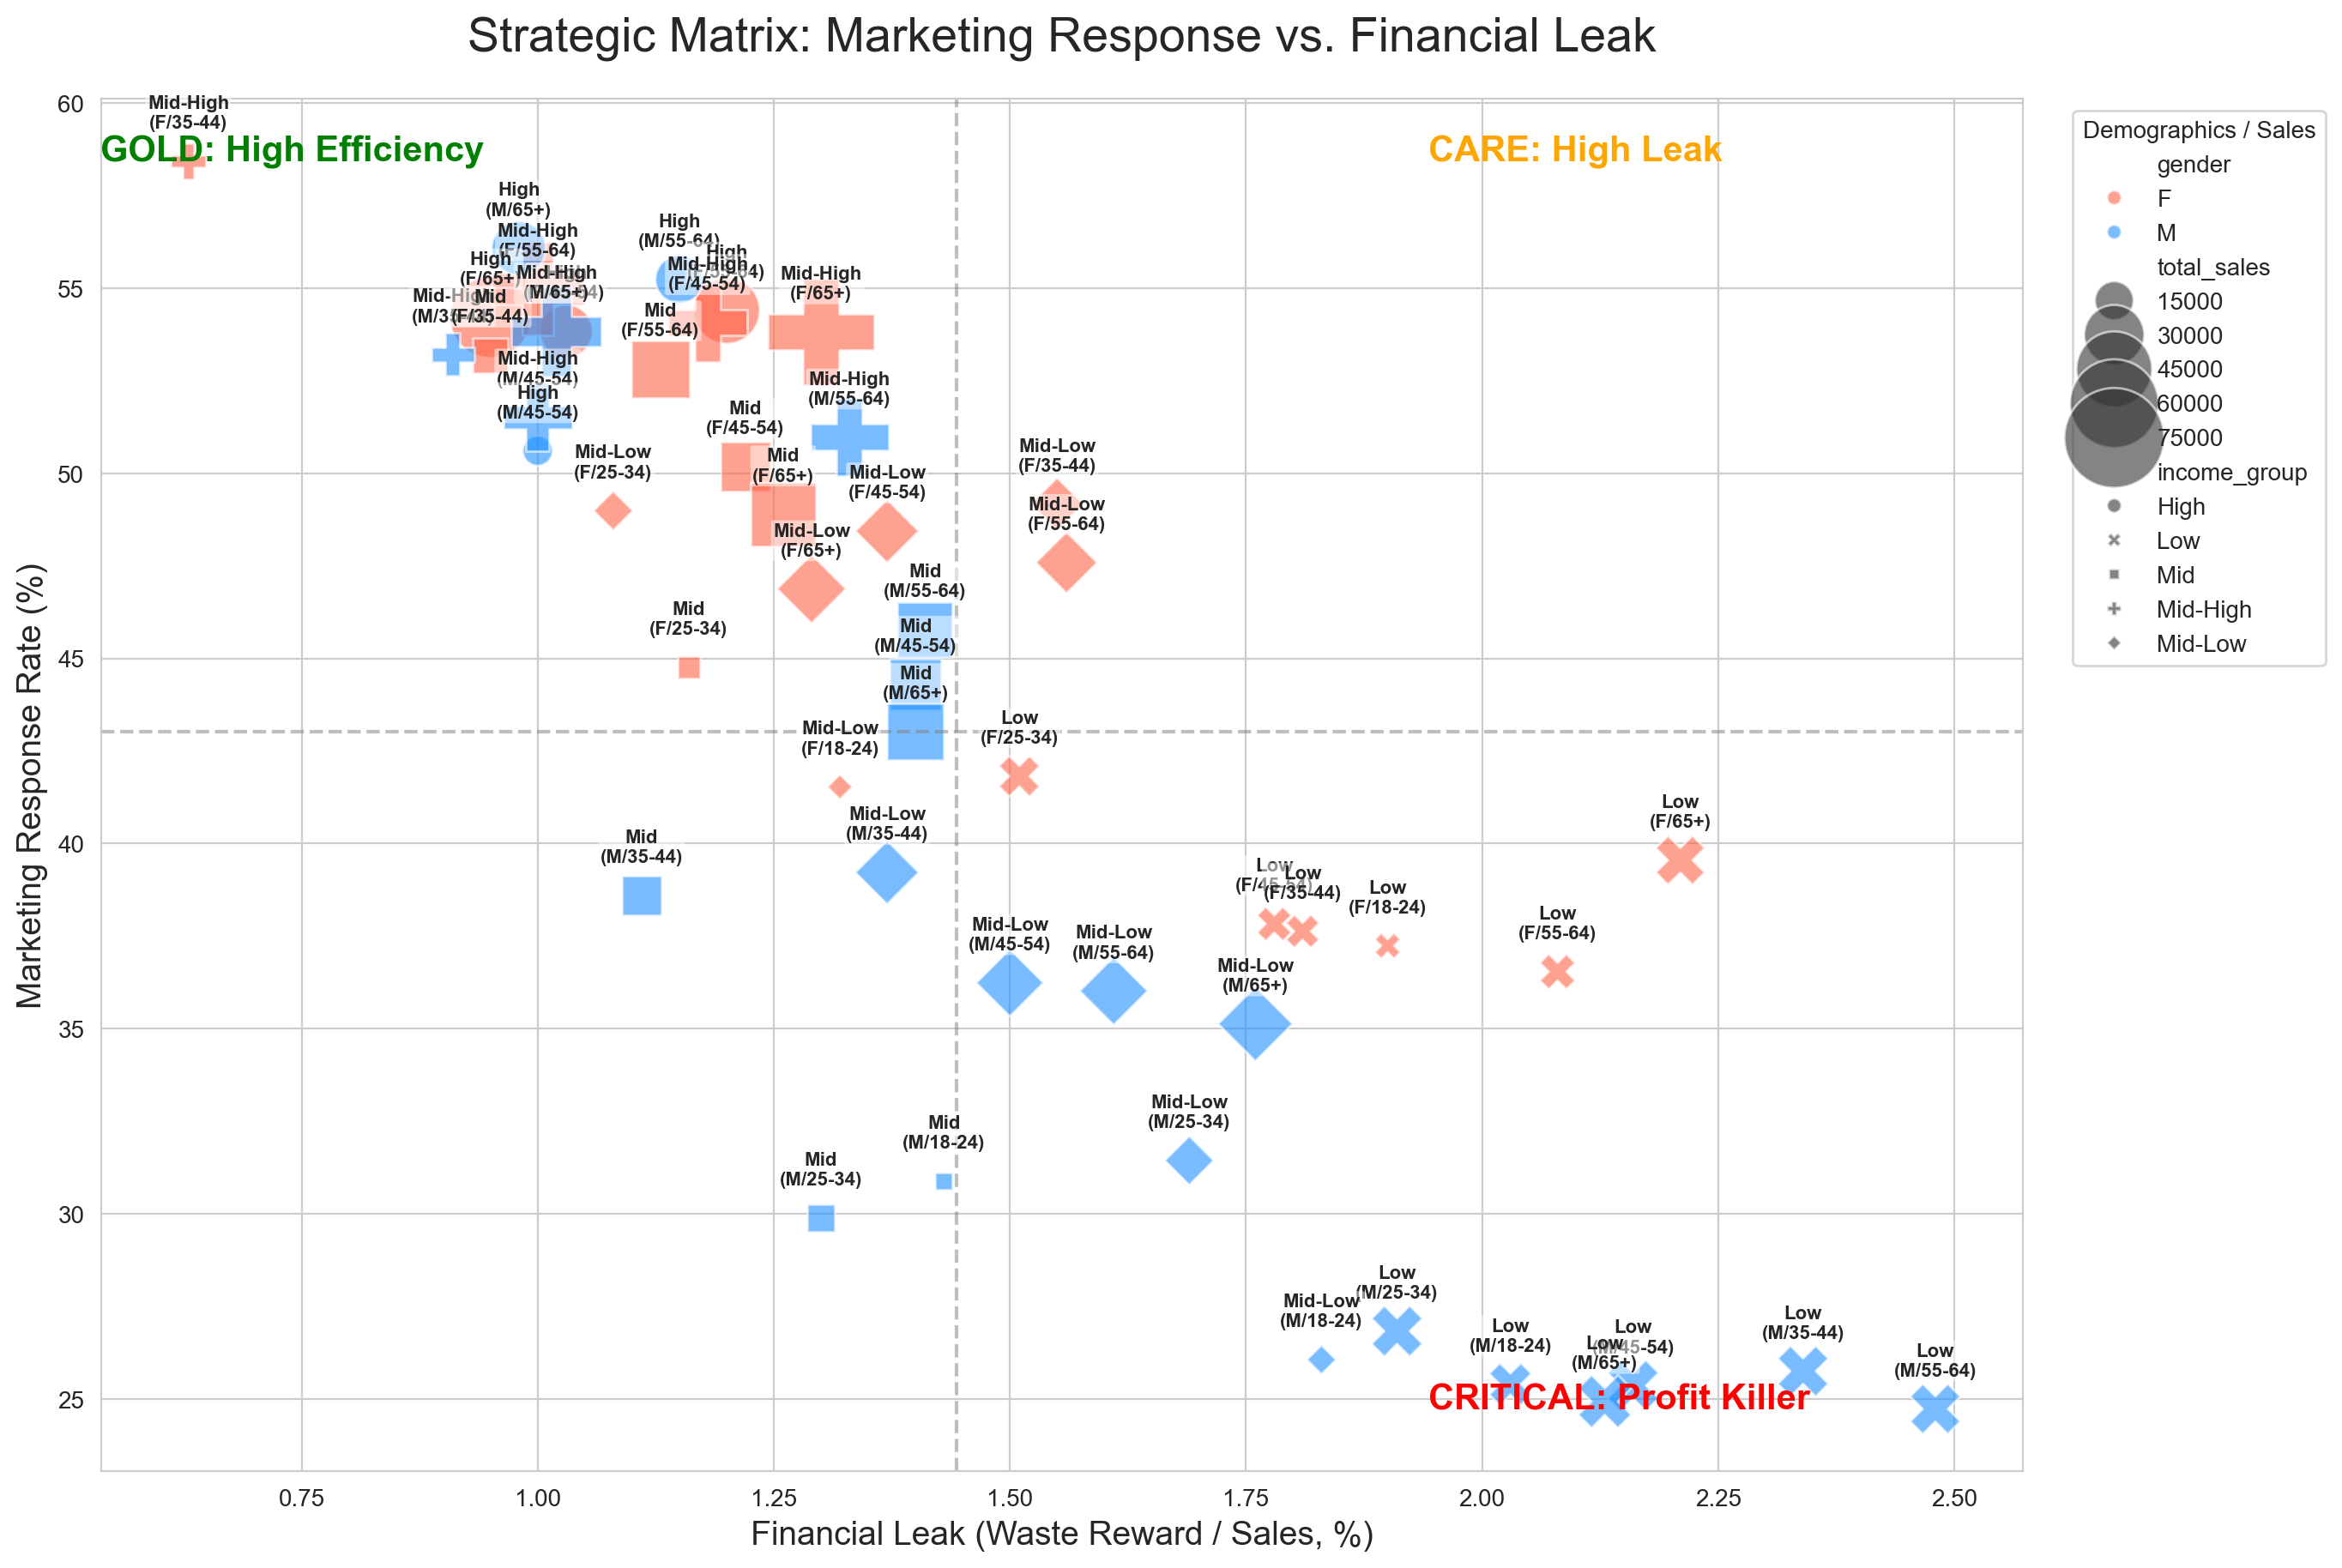

---  Most Critical Segments (High Leak) ---


,gender,income_group,age_group,total_sales,visit_cnt,viewed_comp_cnt,waste_reward_sum,total_rec_cnt,person_cnt,Fin_Loss_Rate,Mkt_Resp_Rate
34,M,Low,55-64,22079.90,4234,498.0,547.0,2014,450,2.48,24.73
32,M,Low,35-44,22450.51,4361,513.0,526.0,1992,441,2.34,25.75
9,F,Low,65+,21235.45,2962,479.0,469.0,1211,271,2.21,39.55
33,M,Low,45-54,22751.85,4493,530.0,492.0,2090,465,2.16,25.36
35,M,Low,65+,24170.25,4924,575.0,514.0,2306,512,2.13,24.93


In [49]:
# 시각화 기본설정
plt.rc('font', family='sans-serif')
plt.rcParams['axes.unicode_minus'] = False
%config InlineBackend.figure_format = 'retina'

# 데이터 그룹화 및 지표 계산 (일렬 현상 방지를 위해 sum 우선 계산)
group_keys = ['gender', 'income_group', 'age_group']

# (A) 매출 데이터
sales_agg = df[df['event'] == 'transaction'].groupby(group_keys).agg(
    total_sales=('amount', 'sum'),
    visit_cnt=('event', 'count')
).reset_index()

# (B) 오퍼 반응 데이터 (누수액 및 반응 건수)
# viewed_before가 NaN이면 안 보고 완료(Leak), True면 보고 완료(Response)
comp_agg = merged_comp.groupby(group_keys).agg(
    viewed_comp_cnt=('viewed_before', lambda x: x.sum()),  # 보고 완료 합계
    waste_reward_sum=('viewed_before', lambda x: (merged_comp.loc[x.index, 'reward'] * x.isna()).sum()) # 안보고 완료한 보상액 합계
).reset_index()

# (C) 오퍼 수령 데이터 (반응률 계산을 위한 분모)
rec = df[df['event'] == 'offer received'].copy()
rec_agg = rec.groupby(group_keys).size().reset_index(name='total_rec_cnt')

# (D) 인원수 데이터
person_agg = df.groupby(group_keys)['person'].nunique().reset_index(name='person_cnt')

# 데이터 병합 (Merge) 및 최종 지표 계산
report = pd.merge(sales_agg, comp_agg, on=group_keys, how='left')
report = pd.merge(report, rec_agg, on=group_keys, how='left')
report = pd.merge(report, person_agg, on=group_keys, how='left').fillna(0)

# 비율 계산
report['Fin_Loss_Rate'] = (report['waste_reward_sum'] / report['total_sales'] * 100).round(2)
report['Mkt_Resp_Rate'] = (report['viewed_comp_cnt'] / report['total_rec_cnt'] * 100).round(2)

# 최소 50명 이상 세그먼트만 필터링
plot_ready = report[report['person_cnt'] >= 50].copy()

# 사분면 시각화
plt.figure(figsize=(16, 10))
sns.set_style("whitegrid")

scatter = sns.scatterplot(
    data=plot_ready, 
    x='Fin_Loss_Rate', 
    y='Mkt_Resp_Rate', 
    hue='gender',
    style='income_group',
    size='total_sales', 
    sizes=(100, 2000), 
    alpha=0.6,
    palette={'M': 'dodgerblue', 'F': 'tomato', 'O': 'green'}
)

# 평균 기준선
loss_mean = plot_ready['Fin_Loss_Rate'].mean()
resp_mean = plot_ready['Mkt_Resp_Rate'].mean()
plt.axvline(loss_mean, color='gray', linestyle='--', alpha=0.5)
plt.axhline(resp_mean, color='gray', linestyle='--', alpha=0.5)

# 상위 반응 세그먼트 20개 레이블링 (겹침 방지)
top_20 = plot_ready.sort_values('Mkt_Resp_Rate', ascending=False).head(50)
for i in range(len(top_20)):
    row = top_20.iloc[i]
    label = f"{row['income_group']}\n({row['gender']}/{row['age_group']})"
    plt.text(row['Fin_Loss_Rate'], row['Mkt_Resp_Rate'] + 0.8, label,
             fontsize=8, ha='center', va='bottom', fontweight='bold',
             bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', boxstyle='round,pad=0.1'))

# 사분면 영역 설명
plt.text(loss_mean - 0.5, plot_ready['Mkt_Resp_Rate'].max(), "GOLD: High Efficiency", fontsize=15, fontweight='bold', ha='right', color='green')
plt.text(loss_mean + 0.5, plot_ready['Mkt_Resp_Rate'].max(), "CARE: High Leak", fontsize=15, fontweight='bold', color='orange')
plt.text(loss_mean + 0.5, plot_ready['Mkt_Resp_Rate'].min(), "CRITICAL: Profit Killer", fontsize=15, fontweight='bold', color='red')

plt.title('Strategic Matrix: Marketing Response vs. Financial Leak', fontsize=20, pad=20)
plt.xlabel('Financial Leak (Waste Reward / Sales, %)', fontsize=14)
plt.ylabel('Marketing Response Rate (%)', fontsize=14)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Demographics / Sales")

# 여백 수동 조정으로 경고 해결
plt.subplots_adjust(left=0.1, right=0.8, top=0.9, bottom=0.1)

plt.show()

# 결과 데이터 요약 출력
print("---  Most Critical Segments (High Leak) ---")
display(plot_ready.sort_values('Fin_Loss_Rate', ascending=False).head(5))

--- [REPORT] 매출 잠식 위험 세그먼트 TOP 10 ---
설명: Cannibalization_Rate가 높을수록 오퍼 없이도 구매했을 고객에게 리워드가 지급된 비중이 높음


,gender,income_group,age_group,total_completed,cannibal_cnt,valid_comp_cnt,Cannibalization_Rate,total_sales,person_cnt
29,M,Low,35-44,646,133,513,20.59,22450.51,441
31,M,Low,55-64,627,129,498,20.57,22079.90,450
27,M,Low,18-24,476,97,379,20.38,16871.76,336
32,M,Low,65+,707,132,575,18.67,24170.25,512
43,M,Mid-Low,18-24,263,48,215,18.25,10327.30,183
30,M,Low,45-54,645,115,530,17.83,22751.85,465
28,M,Low,25-34,652,116,536,17.79,22562.18,444
8,F,Low,65+,579,100,479,17.27,21235.45,271
44,M,Mid-Low,25-34,533,91,442,17.07,21287.94,311
3,F,Low,18-24,233,39,194,16.74,9001.27,112


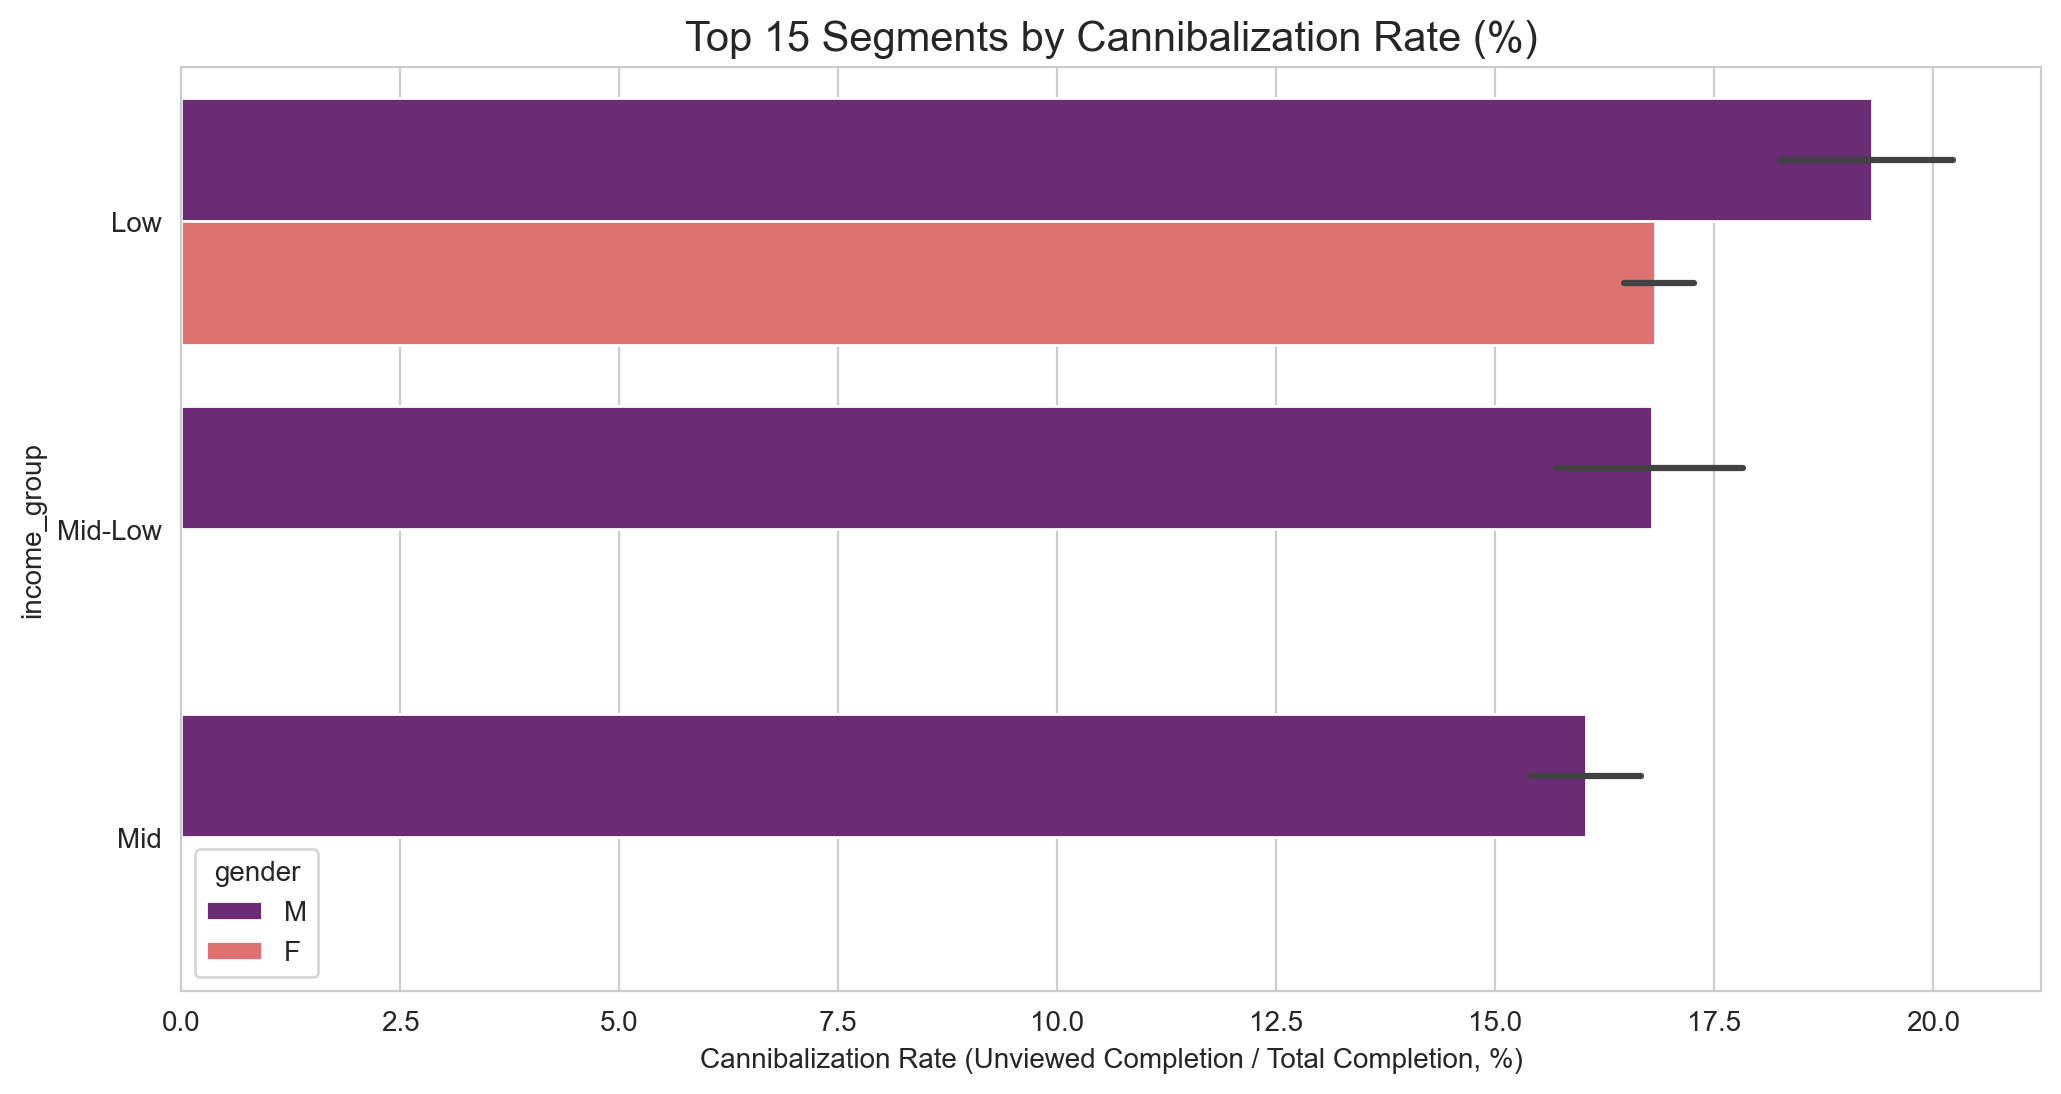

In [50]:
# 세그먼트별 매출 잠식 지표 계산
# cannibal_cnt: 안 보고 완료한 건수 (잠식)
# valid_comp_cnt: 보고 완료한 건수 (실질 마케팅 효과)
cannibal_report = merged_comp.groupby(['gender', 'income_group', 'age_group']).agg(
    total_completed=('person', 'count'),
    cannibal_cnt=('viewed_before', lambda x: x.isna().sum()), # viewed_before가 NaN인 경우
    valid_comp_cnt=('viewed_before', lambda x: x.sum())      # viewed_before가 True인 경우
).reset_index()

# 잠식률(Cannibalization Rate) 계산
# 전체 완료 건수 중 안 보고 완료한 비중
cannibal_report['Cannibalization_Rate'] = (cannibal_report['cannibal_cnt'] / cannibal_report['total_completed'] * 100).round(2)

# 객단가 및 매출 정보를 붙여서 비효율성 확인
# plot_ready(이전 단계에서 만든 데이터)에서 매출 정보 가져오기
cannibal_final = pd.merge(
    cannibal_report, 
    plot_ready[['gender', 'income_group', 'age_group', 'total_sales', 'person_cnt']], 
    on=['gender', 'income_group', 'age_group'], 
    how='inner'
)

# 잠식률이 높은 순서대로 TOP 10 출력
print("--- [REPORT] 매출 잠식 위험 세그먼트 TOP 10 ---")
print("설명: Cannibalization_Rate가 높을수록 오퍼 없이도 구매했을 고객에게 리워드가 지급된 비중이 높음")
display(cannibal_final.sort_values('Cannibalization_Rate', ascending=False).head(10))

# 시각화: 잠식률 - 실제 마케팅 성공 건수
plt.figure(figsize=(12, 6))
sns.barplot(
    data=cannibal_final.sort_values('Cannibalization_Rate', ascending=False).head(15),
    x='Cannibalization_Rate',
    y='income_group', # 혹은 다른 조합
    hue='gender',
    palette='magma'
)
plt.title('Top 15 Segments by Cannibalization Rate (%)', fontsize=15)
plt.xlabel('Cannibalization Rate (Unviewed Completion / Total Completion, %)')
plt.show()

In [51]:
# 기초 데이터 준비 (안 보고 완료한 비율 계산)
# cannibal_cnt: 안 보고 완료(잠식), total_completed: 전체 완료 건수
report_base = cannibal_final.copy()

# 전체 평균 잠식률 (Total Average)
total_cannibal_rate = (report_base['cannibal_cnt'].sum() / report_base['total_completed'].sum() * 100).round(2)

# 함수 정의: 차원별(소득/성별/나이) 잠식률 계산
def get_dim_cannibal(df, dimension):
    dim_df = df.groupby(dimension).agg({
        'cannibal_cnt': 'sum',
        'total_completed': 'sum'
    }).reset_index()
    dim_df['Cannibalization_Rate'] = (dim_df['cannibal_cnt'] / dim_df['total_completed'] * 100).round(2)
    return dim_df.sort_values('Cannibalization_Rate', ascending=False)

# 각 차원별 결과 계산
income_cannibal = get_dim_cannibal(report_base, 'income_group')
gender_cannibal = get_dim_cannibal(report_base, 'gender')
age_cannibal = get_dim_cannibal(report_base, 'age_group')

# 결과 출력
print(f"[전체 평균 잠식률]: {total_cannibal_rate}%")
print("-" * 50)
print("\n[소득별 평균 잠식률]")
display(income_cannibal)
print("\n[성별별 평균 잠식률]")
display(gender_cannibal)
print("\n[나이별 평균 잠식률]")
display(age_cannibal)

[전체 평균 잠식률]: 14.08%
--------------------------------------------------

[소득별 평균 잠식률]


,income_group,cannibal_cnt,total_completed,Cannibalization_Rate
1,Low,1065,5971,17.84
4,Mid-Low,1126,7895,14.26
2,Mid,1043,7886,13.23
0,High,382,3033,12.59
3,Mid-High,861,7019,12.27



[성별별 평균 잠식률]


,gender,cannibal_cnt,total_completed,Cannibalization_Rate
1,M,2505,16455,15.22
0,F,1972,15349,12.85



[나이별 평균 잠식률]


,age_group,cannibal_cnt,total_completed,Cannibalization_Rate
0,18-24,241,1341,17.97
1,25-34,367,2444,15.02
4,55-64,1117,7941,14.07
5,65+,1343,9700,13.85
2,35-44,523,3793,13.79
3,45-54,886,6585,13.45


In [52]:
# 오퍼 완료된 트랜잭션의 ID 리스트 추출 
offer_tx_ids = merged_comp['person'].unique() 

# 오퍼 '전/평소' (Regular): 오퍼와 관련 없는 일반 결제
regular_tx = df[(df['event'] == 'transaction') & (~df['person'].isin(offer_tx_ids))]

# 오퍼 '후/관련' (Offer-Related): 오퍼 조건을 만족해 완료된 결제
# 실제 결제 금액(amount)이 들어있는 df에서 가져와야 정확합니다.
offer_related_tx = df[(df['event'] == 'transaction') & (df['person'].isin(offer_tx_ids))]

#그룹별 평균 계산 (정수로 떨어지지 않게 float 유지)
before_agg = regular_tx.groupby(['gender', 'income_group', 'age_group'])['amount'].mean().reset_index(name='avg_before')
after_agg = offer_related_tx.groupby(['gender', 'income_group', 'age_group'])['amount'].mean().reset_index(name='avg_after')

# 데이터 병합 및 리프트 계산
ticket_analysis = pd.merge(before_agg, after_agg, on=['gender', 'income_group', 'age_group'], how='inner')

# 나눗셈 오류 방지를 위해 0이 아닌 경우만 계산
ticket_analysis = ticket_analysis[ticket_analysis['avg_before'] > 0]
ticket_analysis['Lift_Amount'] = ticket_analysis['avg_after'] - ticket_analysis['avg_before']
ticket_analysis['Lift_Rate_Pct'] = (ticket_analysis['Lift_Amount'] / ticket_analysis['avg_before'] * 100).round(2)

# 결과 확인
print("오퍼 전/후 평균 객단가 데이터")
if len(ticket_analysis) == 0:
    print("매칭되는 데이터가 앖.")
else:
    display(ticket_analysis.sort_values('Lift_Rate_Pct', ascending=False).head(40))

오퍼 전/후 평균 객단가 데이터


,gender,income_group,age_group,avg_before,avg_after,Lift_Amount,Lift_Rate_Pct
53,O,Low,45-54,1.550000,8.888125,7.338125,473.43
52,O,Low,35-44,1.217500,6.848333,5.630833,462.49
60,O,Mid-Low,18-24,3.075000,13.459804,10.384804,337.72
64,O,Mid-Low,55-64,3.868333,15.314412,11.446078,295.89
9,F,Mid,18-24,3.550750,13.965207,10.414457,293.30
10,F,Mid,25-34,3.316250,12.856394,9.540144,287.68
19,F,Mid-Low,18-24,2.746977,10.563888,7.816911,284.56
51,O,Low,25-34,2.067273,6.883889,4.816616,232.99
62,O,Mid-Low,35-44,3.229000,10.048125,6.819125,211.18
36,M,Mid,35-44,4.079398,12.091617,8.012219,196.41


In [53]:
# offer_metrics 로드 — 02_funnel_analysis.ipynb 실행 후 생성된 파일
offer_metrics = pd.read_csv('../data/processed/offer_metrics.csv')
print(f'offer_metrics 로드 완료: {offer_metrics.shape}')

offer_metrics 로드 완료: (119702, 32)


In [54]:
# STEP 1. A/B/C 타겟 유형 라벨링

# A:오퍼 보고 구매(마케팅 핵심타겟)
# B:오퍼 보고 미구매(설득 가능타겟)
# C: 오퍼 안보고 구매(마케팅 비기여타겟)

offer_metrics['target_group'] = np.select(
    [(offer_metrics['is_viewed'] == True) & (offer_metrics['is_completed'] == True),
     (offer_metrics['is_viewed'] == True) & (offer_metrics['is_completed'] == False),
     (offer_metrics['is_viewed'] == False) & (offer_metrics['is_completed'] == True)
    ],
    ['A_Viewed_and_Completed',     # 핵심타겟
     'B_Viewed_not_Completed',     # 설득대상
     'C_Completed_without_View'   # 비기여타겟
    ],
    default='Other' #오퍼무반응
)

offer_metrics['target_group'].value_counts()

target_group
A_Viewed_and_Completed      52774
B_Viewed_not_Completed      36327
Other                       19375
C_Completed_without_View    11226
Name: count, dtype: int64

In [55]:
# 소득 × 나이 세그먼트별 타겟 그룹 비중 (%)
income_age_target_pct = (
    offer_metrics
    .groupby(['income_g', 'age_g', 'target_group'], observed=True)
    .size()
    .groupby(level=[0, 1])
    .transform(lambda x: x / x.sum())
    .unstack('target_group')
    .mul(100)
    .round(1)
)
income_age_target_pct 

target_group       A_Viewed_and_Completed  B_Viewed_not_Completed  \
income_g age_g                                                      
High-End 35-44                       63.4                    30.9   
         45-54                       55.1                    25.2   
         55-64                       54.1                    23.5   
         65+                         55.9                    21.6   
Low-End  25-34                       32.9                    35.9   
         35-44                       30.3                    36.7   
         45-54                       29.5                    36.8   
         55-64                       30.6                    37.4   
         65+                         31.1                    37.0   
         under_24                    30.5                    38.9   
Mid-High 25-34                       34.6                    35.0   
         35-44                       48.9                    31.3   
         45-54                       50.9                    28.8   
         55-64                       50.9                    25.9   
         65+                         48.2                    27.6   
         under_24                    36.6                    30.3   
Mid-Low  25-34                       37.3                    31.8   
         35-44                       47.1                    31.7   
         45-54                       46.1                    34.0   
         55-64                       46.1                    34.2   
         65+                         46.0                    34.4   
         under_24                    31.5                    35.9   
VIP      35-44                       88.2                     8.8   
         45-54                       48.8                    18.2   
         55-64                       50.0                    15.8   
         65+                         49.7                    16.5   

target_group       C_Completed_without_View  Other  
income_g age_g                                      
High-End 35-44                          2.9    2.7  
         45-54                         10.6    9.1  
         55-64                         12.1   10.3  
         65+                           12.4   10.0  
Low-End  25-34                          7.6   23.7  
         35-44                          8.3   24.6  
         45-54                          8.4   25.3  
         55-64                          7.9   24.1  
         65+                            8.6   23.3  
         under_24                       7.9   22.7  
Mid-High 25-34                          9.9   20.5  
         35-44                          6.4   13.4  
         45-54                          8.3   11.9  
         55-64                         11.0   12.2  
         65+                           10.0   14.1  
         under_24                       9.9   23.2  
Mid-Low  25-34                          9.1   21.8  
         35-44                          7.1   14.1  
         45-54                          6.3   13.6  
         55-64                          6.3   13.4  
         65+                            5.8   13.9  
         under_24                       9.3   23.3  
VIP      35-44                          NaN    2.9  
         45-54                         17.9   15.1  
         55-64                         18.9   15.3  
         65+                           18.3   15.5

In [56]:
# Net Lift Index 계산
income_age_target_pct['net_lift_index'] = (
    (income_age_target_pct['A_Viewed_and_Completed']
     - income_age_target_pct['C_Completed_without_View']) /
    (income_age_target_pct['A_Viewed_and_Completed']
     + income_age_target_pct['C_Completed_without_View'])
)


#리워드 잠식률 (Cannibalization Rate)- 오퍼 수혜자 중 '안 보고도 사용한 비율'
income_age_target_pct['cannibalization_rate'] = (
    income_age_target_pct['C_Completed_without_View'] /
    (income_age_target_pct['A_Viewed_and_Completed']
     + income_age_target_pct['C_Completed_without_View'])
)
#전략 세그먼트 분류
#기준: net_lift_index 중앙값(0.63), cannibalization_rate 중앙값(0.18)
income_age_target_pct['strategy_group'] = np.select(
    [
        #오퍼가 실제로 매출을 만드는 그룹
        (income_age_target_pct['net_lift_index'] >= 0.63) &
        (income_age_target_pct['cannibalization_rate'] < 0.18),

        #오퍼 없이도 구매 → 비용만 발생하는 그룹
        (income_age_target_pct['net_lift_index'] < 0.63) &
        (income_age_target_pct['cannibalization_rate'] >= 0.18),

        #잘 사지만 리워드 잠식도 큰 그룹 → 조건 조정
        (income_age_target_pct['net_lift_index'] >= 0.63) &
        (income_age_target_pct['cannibalization_rate'] >= 0.18)
    ],
    ['오퍼 유지·확대',
     '활성화 허들 도입',
     '리워드 조건 상향'
    ],
    default='현 상태 유지·관찰'
)

income_age_target_pct

target_group       A_Viewed_and_Completed  B_Viewed_not_Completed  \
income_g age_g                                                      
High-End 35-44                       63.4                    30.9   
         45-54                       55.1                    25.2   
         55-64                       54.1                    23.5   
         65+                         55.9                    21.6   
Low-End  25-34                       32.9                    35.9   
         35-44                       30.3                    36.7   
         45-54                       29.5                    36.8   
         55-64                       30.6                    37.4   
         65+                         31.1                    37.0   
         under_24                    30.5                    38.9   
Mid-High 25-34                       34.6                    35.0   
         35-44                       48.9                    31.3   
         45-54                       50.9                    28.8   
         55-64                       50.9                    25.9   
         65+                         48.2                    27.6   
         under_24                    36.6                    30.3   
Mid-Low  25-34                       37.3                    31.8   
         35-44                       47.1                    31.7   
         45-54                       46.1                    34.0   
         55-64                       46.1                    34.2   
         65+                         46.0                    34.4   
         under_24                    31.5                    35.9   
VIP      35-44                       88.2                     8.8   
         45-54                       48.8                    18.2   
         55-64                       50.0                    15.8   
         65+                         49.7                    16.5   

target_group       C_Completed_without_View  Other  net_lift_index  \
income_g age_g                                                       
High-End 35-44                          2.9    2.7        0.912519   
         45-54                         10.6    9.1        0.677321   
         55-64                         12.1   10.3        0.634441   
         65+                           12.4   10.0        0.636896   
Low-End  25-34                          7.6   23.7        0.624691   
         35-44                          8.3   24.6        0.569948   
         45-54                          8.4   25.3        0.556728   
         55-64                          7.9   24.1        0.589610   
         65+                            8.6   23.3        0.566751   
         under_24                       7.9   22.7        0.588542   
Mid-High 25-34                          9.9   20.5        0.555056   
         35-44                          6.4   13.4        0.768535   
         45-54                          8.3   11.9        0.719595   
         55-64                         11.0   12.2        0.644588   
         65+                           10.0   14.1        0.656357   
         under_24                       9.9   23.2        0.574194   
Mid-Low  25-34                          9.1   21.8        0.607759   
         35-44                          7.1   14.1        0.738007   
         45-54                          6.3   13.6        0.759542   
         55-64                          6.3   13.4        0.759542   
         65+                            5.8   13.9        0.776062   
         under_24                       9.3   23.3        0.544118   
VIP      35-44                          NaN    2.9             NaN   
         45-54                         17.9   15.1        0.463268   
         55-64                         18.9   15.3        0.451379   
         65+                           18.3   15.5        0.461765   

target_group       cannibalization_rate strategy_group  
income_g age_g                                   

In [57]:
# 전략 그룹별 세그먼트 비율
strategy_dist_pct = (
    income_age_target_pct['strategy_group']
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
    .to_frame(name='segment_pct')
)
strategy_dist_pct 

,segment_pct
strategy_group,
활성화 허들 도입,50.0
오퍼 유지·확대,38.5
리워드 조건 상향,7.7
현 상태 유지·관찰,3.8


posx and posy should be finite values


posx and posy should be finite values


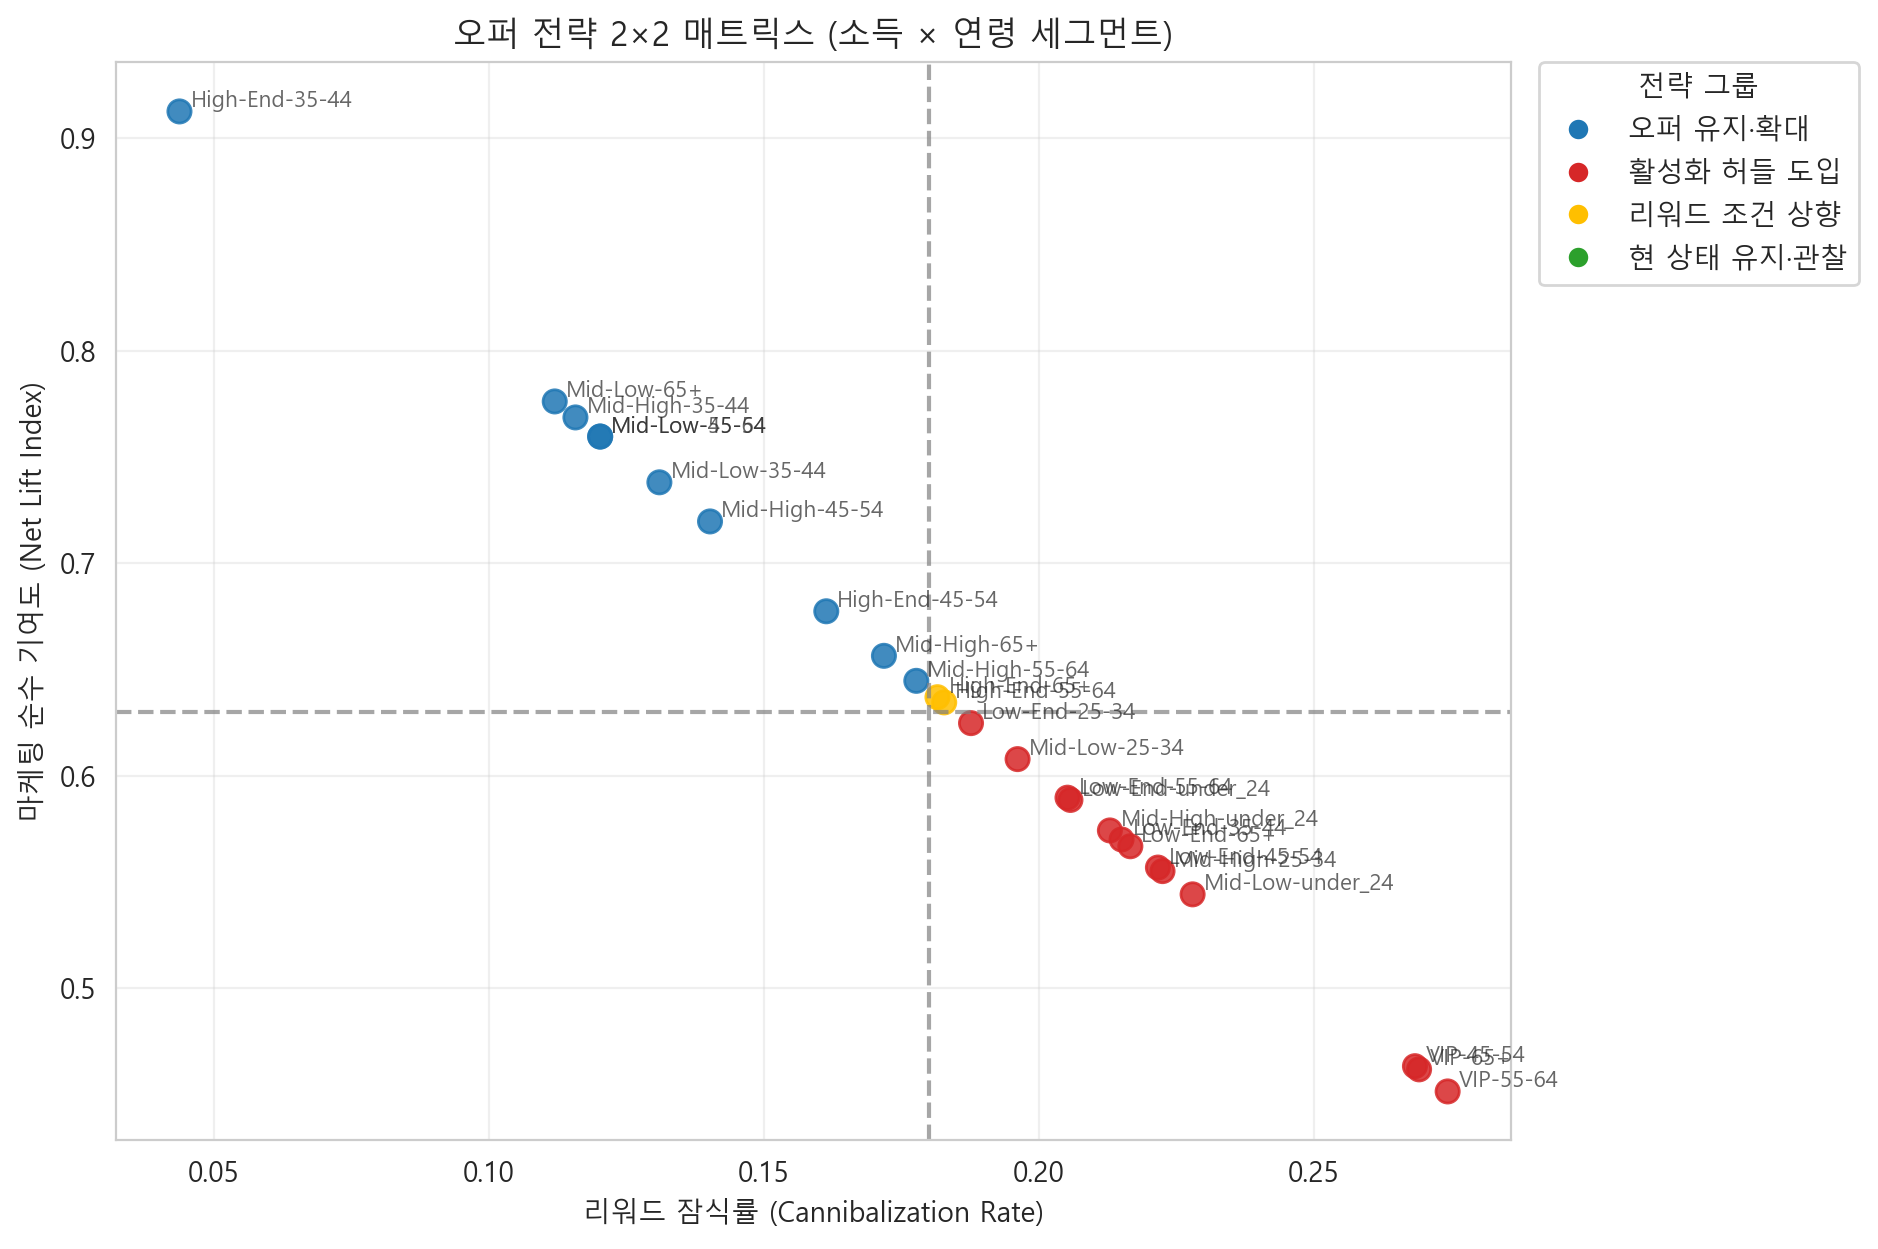

In [58]:
from matplotlib.lines import Line2D
# 2×2 전략 매트릭스 시각화 (Net Lift × Cannibalization)
import matplotlib.pyplot as plt 
plt.rcParams['font.family'] = 'Malgun Gothic'


color_map = {
    '오퍼 유지·확대': '#1f77b4',        #파랑
    '활성화 허들 도입': '#d62728',      #빨강
    '리워드 조건 상향': '#ffbf00',      #노랑
    '현 상태 유지·관찰': '#2ca02c'      #초록
}
plt.figure(figsize=(9, 7))

#산점도 (전략 그룹별 색상)
plt.scatter(
    income_age_target_pct['cannibalization_rate'],
    income_age_target_pct['net_lift_index'],
    c=income_age_target_pct['strategy_group'].map(color_map),
    s=70,
    alpha=0.85
)

#기준선 (중앙값 기준)
plt.axhline(0.63, linestyle='--', color='gray', alpha=0.7)
plt.axvline(0.18, linestyle='--', color='gray', alpha=0.7)

#소득 × 나이 라벨 붙이기
for (income, age), row in income_age_target_pct.iterrows():
    plt.text(
        row['cannibalization_rate'] + 0.002,
        row['net_lift_index'] + 0.002,
        f"{income}-{age}",
        fontsize=8,
        alpha=0.7
    )

#범례 생성
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           label='오퍼 유지·확대',
           markerfacecolor='#1f77b4', markersize=8),

    Line2D([0], [0], marker='o', color='w',
           label='활성화 허들 도입',
           markerfacecolor='#d62728', markersize=8),

    Line2D([0], [0], marker='o', color='w',
           label='리워드 조건 상향',
           markerfacecolor='#ffbf00', markersize=8),

    Line2D([0], [0], marker='o', color='w',
           label='현 상태 유지·관찰',
           markerfacecolor='#2ca02c', markersize=8),
]

plt.legend(
    handles=legend_elements,
    title='전략 그룹',
    bbox_to_anchor=(1.02, 1),  
    loc='upper left',
    borderaxespad=0.
)

#축 / 제목
plt.xlabel('리워드 잠식률 (Cannibalization Rate)')
plt.ylabel('마케팅 순수 기여도 (Net Lift Index)')
plt.title('오퍼 전략 2×2 매트릭스 (소득 × 연령 세그먼트)')

plt.grid(alpha=0.3)
plt.show()

In [59]:
# A타입(오퍼 반응 구매) vs C타입(우연완료) 비중 계산

# 전체 완료 오퍼 수 (A + C)
total_completed_cnt = offer_metrics['completed'].sum()
# C타입 완료 오퍼 수
c_completed_cnt = offer_metrics['completed_wo_view'].sum()
# A타입 완료 오퍼 수
a_completed_cnt = total_completed_cnt - c_completed_cnt

# 완료 기준 비율 (%)
a_completed_pct = round(a_completed_cnt / total_completed_cnt * 100, 2)
c_completed_pct = round(c_completed_cnt / total_completed_cnt * 100, 2)

#2. A타입 vs C타입 리워드 비교
# 전체 완료 오퍼 리워드 비용
total_reward_cost = (offer_metrics.loc[offer_metrics['completed'] == 1,'reward'].sum())
#C타입 완료 오퍼 리워드 비용
c_reward_cost = (offer_metrics.loc[offer_metrics['completed_wo_view'] == 1,'reward'].sum())
# A타입 완료 오퍼 리워드 비용
a_reward_cost = total_reward_cost - c_reward_cost
# 비용 기준 비율 (%)
a_reward_cost_pct = round(a_reward_cost / total_reward_cost * 100, 2)
c_reward_cost_pct = round(c_reward_cost / total_reward_cost * 100, 2)

# 평균 리워드 비용 비교 
avg_reward_a = ( offer_metrics.loc[offer_metrics['viewed_then_completed'] == True,'reward'].mean()).round(2)
avg_reward_c = (offer_metrics.loc[offer_metrics['completed_wo_view'] == 1,'reward'].mean()).round(2)
# ---------------------------------------------------------
# 기초통계 요약 테이블
summary = pd.DataFrame({
    '구분': ['A타입 (확인 후 완료)', 'C타입 (미확인 완료)'],
    '완료 건수': [a_completed_cnt, c_completed_cnt],
    '완료 비중(%)': [a_completed_pct, c_completed_pct],
    '리워드 비용': [a_reward_cost, c_reward_cost],
    '리워드 비용 비중(%)': [a_reward_cost_pct, c_reward_cost_pct],
    '평균 리워드 비용': [avg_reward_a,avg_reward_c]
})

summary

,구분,완료 건수,완료 비중(%),리워드 비용,리워드 비용 비중(%),평균 리워드 비용
0,A타입 (확인 후 완료),52774,82.46,132244.0,83.49,4.92
1,C타입 (미확인 완료),11226,17.54,26157.0,16.51,4.66
